# Comparative Brain-Tumour Detection with YOLOv7-tiny and YOLOv8n

## Final evaluated project notebook

This project compares two compact one-stage CNN object detectors for localizing and classifying tumours in 2D contrast-enhanced T1 MRI slices. The comparison uses a fixed patient-level split, controlled training settings, a held-out test set, common metric code, and visual error analysis.

**Research question:** Under the same patient-level split and training budget, does YOLOv8n improve localization and classification over YOLOv7-tiny?

**Classes:** glioma, meningioma, and pituitary tumour.

**Important scope restriction:** this is an educational research prototype. It is not a medical device and must not be used for diagnosis, screening, triage, treatment, or patient-specific decisions.

### Reproducibility note

Run the notebook from top to bottom in a Google Colab T4 GPU runtime. Package versions, the YOLOv7 commit, random seed, patient assignments, checkpoints, and epoch completion are validated in code. The independent test set is not used for training, checkpoint selection, or hyperparameter selection.


### Code — connect persistent storage

Mount Google Drive so the dataset archive, checkpoints, and evaluation artefacts survive a Colab runtime restart.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### Code — import analysis tools and define paths

Load the libraries used for file handling, tabular analysis, image inspection, and plotting. A fixed seed makes sampling and training choices reproducible.


In [ ]:
from pathlib import Path
import csv
import random
import shutil
import zipfile

import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.patches import Rectangle
from PIL import Image

DATASET_ROOT = Path('/content/brain-tumor-yolo-colab')
ARCHIVE = Path('/content/brain-tumor-yolo-colab.zip')
SEED = 41
print('Dataset destination:', DATASET_ROOT)

Dataset destination: /content/brain-tumor-yolo-colab


## Upload and extract the prepared dataset

The upload archive contains 3,064 MRI PNG images, one YOLO label per image, a patient-level split, and a portable CSV manifest. The upload may take several minutes because the ZIP is approximately 350 MB.

### Code — extract and validate the prepared dataset

Extract the archive and verify the required manifest and dataset configuration before any analysis begins.


In [ ]:
drive_archive_candidates = [
    Path("/content/drive/MyDrive/brain-tumor-yolo-colab.zip"),
    Path(
        "/content/drive/MyDrive/brain_tumor_multimodal_project/"
        "brain-tumor-yolo-colab.zip"
    ),
]

if not ARCHIVE.exists():
    drive_archive = next(
        (path for path in drive_archive_candidates if path.exists()),
        None,
    )

    if drive_archive is not None:
        shutil.copy2(drive_archive, ARCHIVE)
        print("Dataset archive copied from:", drive_archive)
    else:
        from google.colab import files

        print("Choose brain-tumor-yolo-colab.zip")
        uploaded = files.upload()
        uploaded_zip = next(
            (Path("/content") / name for name in uploaded if name.endswith(".zip")),
            None,
        )
        if uploaded_zip is None:
            raise FileNotFoundError("No ZIP archive was uploaded.")
        if uploaded_zip != ARCHIVE:
            uploaded_zip.rename(ARCHIVE)

if DATASET_ROOT.exists():
    shutil.rmtree(DATASET_ROOT)

with zipfile.ZipFile(ARCHIVE) as archive:
    archive.extractall("/content")

required = [DATASET_ROOT / "manifest.csv", DATASET_ROOT / "dataset.yaml"]
assert all(path.exists() for path in required), "Unexpected archive structure."
print("Dataset extracted and validated successfully.")


Dataset archive copied from: /content/drive/MyDrive/brain-tumor-yolo-colab.zip
Dataset extracted and validated successfully.


# Phase 1 — Define the scope

**Research question:** Under the same patient-level split and training budget, does YOLOv8n improve localization and classification over YOLOv7-tiny?

- Input: one 2D T1-weighted contrast-enhanced MRI slice.
- Output: bounding box, confidence, and tumor class.
- Classes: glioma, meningioma, and pituitary tumor.
- Independent unit: patient; slices from one patient are repeated observations.
- Exclusion: clinical diagnosis or deployment.
- Important limitation: the selected dataset has no healthy/no-tumor controls.

### Code — record the research specification

Store the task, inputs, classes, candidate models, evaluation metrics, and clinical exclusion in a machine-readable object.


In [ ]:
research_specification = {
    'task': '2D object detection and three-class tumor classification',
    'inputs': 'T1-weighted contrast-enhanced MRI slices',
    'classes': ['glioma', 'meningioma', 'pituitary'],
    'independent_unit': 'patient',
    'candidate_models': ['YOLOv7-tiny', 'YOLOv8n'],
    'primary_metrics': ['mAP50', 'mAP50-95', 'precision', 'recall', 'F1'],
    'clinical_use': False,
}
pd.Series(research_specification, name='Project specification')

,Project specification
task,2D object detection and three-class tumor clas...
inputs,T1-weighted contrast-enhanced MRI slices
classes,"[glioma, meningioma, pituitary]"
independent_unit,patient
candidate_models,"[YOLOv7-tiny, YOLOv8n]"
primary_metrics,"[mAP50, mAP50-95, precision, recall, F1]"
clinical_use,False


# Phase 2 — Select and audit the data

The Jun Cheng dataset contains 3,064 T1 contrast-enhanced MRI slices from 233 patients. Source labels are remapped into detector IDs `0=glioma`, `1=meningioma`, and `2=pituitary`. The original files include patient IDs and binary tumor masks, making patient-level splitting and mask-to-box conversion possible.

### Code — load the manifest and inspect dataset composition

The manifest connects each slice to its patient, class, image, label, bounding box, and split. The tables provide the first dataset sanity check.


In [ ]:
manifest_path = DATASET_ROOT / 'manifest.csv'
df = pd.read_csv(manifest_path, dtype={'patient_id': str, 'sample_id': str})
print(f'Slices: {len(df):,}')
print(f'Patients: {df.patient_id.nunique():,}')

#display the dataset
display(pd.crosstab(df['class_name'], df['split'], margins=True))
display(df.head())

Slices: 3,064
Patients: 233


split,test,train,val,All
class_name,,,,
glioma,240,939,247,1426
meningioma,112,499,97,708
pituitary,189,589,152,930
All,541,2027,496,3064


,sample_id,patient_id,source_file,image_path,label_path,class_id,class_name,has_tumor,orientation,width,height,bbox_xmin,bbox_ymin,bbox_xmax,bbox_ymax,split
0,1,100360,original-mat/1.mat,images/train/1.png,labels/train/1.txt,1,meningioma,1,unknown,512,512,176,267,252,379,train
1,10,101016,original-mat/10.mat,images/train/10.png,labels/train/10.txt,1,meningioma,1,unknown,512,512,251,236,324,299,train
2,100,107494,original-mat/100.mat,images/test/100.png,labels/test/100.txt,1,meningioma,1,unknown,512,512,176,178,265,217,test
3,1000,112649,original-mat/1000.mat,images/train/1000.png,labels/train/1000.txt,2,pituitary,1,unknown,512,512,204,225,240,274,train
4,1001,112649,original-mat/1001.mat,images/train/1001.png,labels/train/1001.txt,2,pituitary,1,unknown,512,512,203,225,242,279,train


#### Result interpretation

The manifest contains **3,064 MRI slices from 233 patients**. Glioma is the largest class, followed by pituitary and meningioma, so aggregate metrics should always be accompanied by class-level results.


### Code — audit patient leakage and expected counts

Every patient must belong to exactly one split. Assertions stop the notebook immediately if the prepared data no longer match the documented dataset.


In [ ]:
# The same patient must never occur in multiple splits.
splits_per_patient = df.groupby('patient_id')['split'].nunique()
#data integrity checks
assert splits_per_patient.max() == 1, 'Patient leakage detected.'

expected_slices = {'glioma': 1426, 'meningioma': 708, 'pituitary': 930}
actual_slices = df['class_name'].value_counts().to_dict()
assert actual_slices == expected_slices, (actual_slices, expected_slices)
assert len(df) == 3064
assert df.patient_id.nunique() == 233

patient_summary = df.groupby('split')['patient_id'].nunique().reindex(['train', 'val', 'test'])
slice_summary = df['split'].value_counts().reindex(['train', 'val', 'test'])
display(pd.DataFrame({'slices': slice_summary, 'patients': patient_summary}))
print('Patient-level split audit passed: no leakage detected.')

,slices,patients
split,,
train,2027,162
val,496,34
test,541,37


Patient-level split audit passed: no leakage detected.


#### Result interpretation

The audit reports **zero patient leakage**: 162 patients are used for training, 34 for validation, and 37 for testing. This is essential because slices from the same patient are correlated observations.


### Code — visualize class balance

Plot the overall class distribution and the distribution within each patient-level subset.


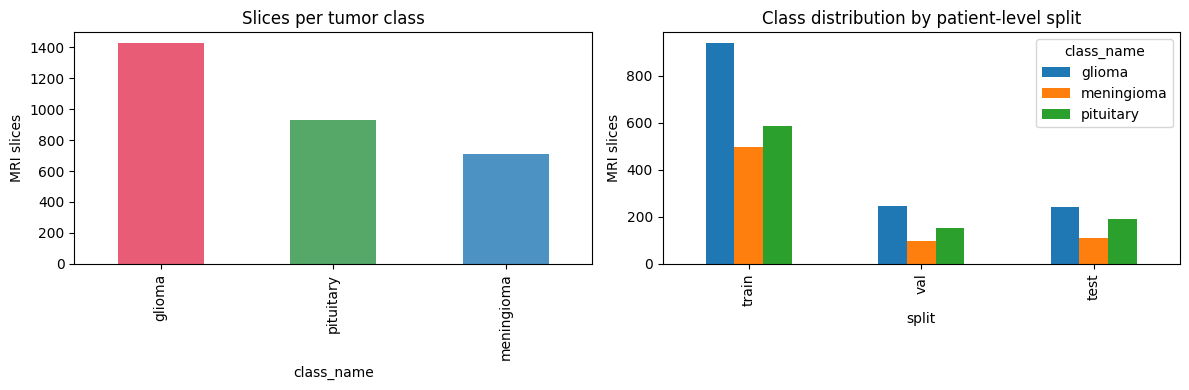

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df['class_name'].value_counts().plot.bar(ax=axes[0], color=['#e85d75', '#55a868', '#4c92c3'])
axes[0].set_title('Slices per tumor class')
axes[0].set_ylabel('MRI slices')
df.groupby(['split', 'class_name']).size().unstack().reindex(['train', 'val', 'test']).plot.bar(ax=axes[1])
axes[1].set_title('Class distribution by patient-level split')
axes[1].set_ylabel('MRI slices')
plt.tight_layout()
plt.show()

#### Result interpretation

The three splits preserve all tumour classes, but they are not perfectly balanced by slice count. AP is therefore reported separately for each class as well as averaged across classes.


# Phase 3 — Prepare and validate YOLO annotations

Each binary mask was reduced to its tight axis-aligned bounding box. YOLO stores a box as `class_id x_center y_center width height`, with all four coordinates normalized to the interval 0–1. Because this source contains only tumor-positive images, every label file contains one tumor record. A future healthy image would use an empty label file.

### Code — convert masks and pixel boxes into YOLO coordinates

The helper functions turn a binary mask into an inclusive pixel bounding box and then normalize that box into YOLO's centre-width-height format.


In [ ]:
def mask_to_bbox(mask):
    """Convert a binary mask to inclusive xmin, ymin, xmax, ymax coordinates."""
    import numpy as np

    rows, columns = np.where(mask > 0)

    if rows.size == 0:
        raise ValueError('The tumor mask is empty.')

    return int(columns.min()), int(rows.min()), int(columns.max()), int(rows.max())

def bbox_to_yolo(bbox, image_width, image_height):
    """Convert an inclusive pixel box to normalized YOLO coordinates."""
    xmin, ymin, xmax, ymax = bbox
    box_width = xmax - xmin + 1
    box_height = ymax - ymin + 1
    return (
        (xmin + xmax + 1) / (2 * image_width),
        (ymin + ymax + 1) / (2 * image_height),
        box_width / image_width,
        box_height / image_height,
    )

### Code — perform a complete annotation audit

Check every image/label pair, label length, class ID, normalized coordinate range, and agreement with the bounding box stored in the manifest.


In [ ]:
# Verify every image and YOLO label in the uploaded archive.
import numpy as np

errors = []

for row in df.itertuples(index=False):
    image_path = DATASET_ROOT / row.image_path
    label_path = DATASET_ROOT / row.label_path

    if not image_path.exists() or not label_path.exists():
        errors.append(f"Missing files for sample {row.sample_id}")
        continue

    parts = label_path.read_text().strip().split()

    if len(parts) != 5:
        errors.append(f"Expected one five-value label for sample {row.sample_id}")
        continue

    try:
        class_id = int(parts[0])
        coordinates = np.asarray([float(value) for value in parts[1:]], dtype=float)
    except ValueError:
        errors.append(f"Non-numeric label for sample {row.sample_id}")
        continue

    expected_coordinates = np.asarray(
        bbox_to_yolo(
            (row.bbox_xmin, row.bbox_ymin, row.bbox_xmax, row.bbox_ymax),
            row.width,
            row.height,
        ),
        dtype=float,
    )

    if class_id != row.class_id:
        errors.append(f"Class mismatch for sample {row.sample_id}")
    elif not np.all(np.isfinite(coordinates)):
        errors.append(f"Non-finite coordinates for sample {row.sample_id}")
    elif not np.all((0 <= coordinates) & (coordinates <= 1)):
        errors.append(f"Coordinates outside [0, 1] for sample {row.sample_id}")
    elif not np.allclose(coordinates, expected_coordinates, atol=1e-5):
        errors.append(f"Manifest/label box mismatch for sample {row.sample_id}")

assert not errors, errors[:10]
print(f"Annotation audit passed for {len(df):,} images and labels.")


Annotation audit passed for 3,064 images and labels.


#### Result interpretation

All 3,064 image/label pairs pass structural and coordinate checks. The strengthened audit also requires each label to reproduce the manifest bounding box within numerical tolerance.


### Code — visually inspect representative annotations

Numerical validity cannot reveal every annotation error. Drawing deterministic examples catches swapped axes, incorrect scaling, or anatomically misplaced boxes.


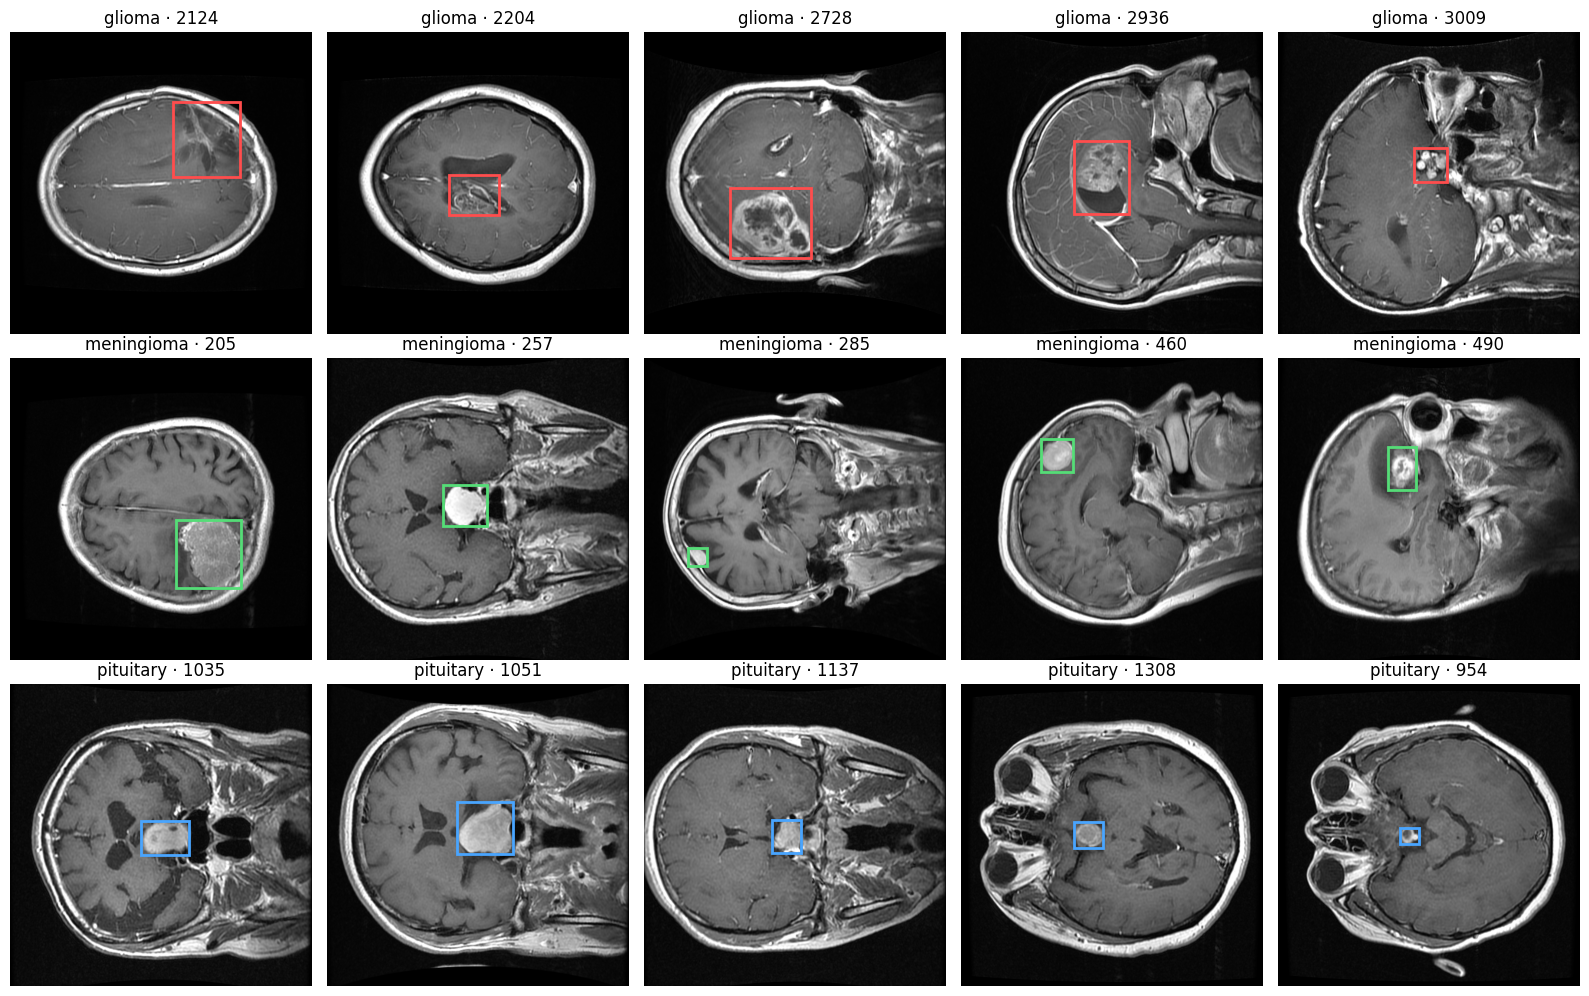

In [ ]:
# Visual audit: five deterministic random boxes per class.
sample_rows = (df.groupby('class_name', group_keys=False)
                 .sample(n=5, random_state=SEED)
                 .sort_values(['class_name', 'sample_id']))
colors = {'glioma': '#ff4d4d', 'meningioma': '#55dd77', 'pituitary': '#49a5ff'}
fig, axes = plt.subplots(3, 5, figsize=(16, 10))
for axis, row in zip(axes.flat, sample_rows.itertuples(index=False)):
    image = Image.open(DATASET_ROOT / row.image_path)
    axis.imshow(image, cmap='gray')
    width = row.bbox_xmax - row.bbox_xmin + 1
    height = row.bbox_ymax - row.bbox_ymin + 1
    axis.add_patch(Rectangle((row.bbox_xmin, row.bbox_ymin), width, height,
                             fill=False, linewidth=2, edgecolor=colors[row.class_name]))
    axis.set_title(f'{row.class_name} · {row.sample_id}')
    axis.axis('off')
plt.tight_layout()
plt.show()

#### Result interpretation

The sampled overlays place one tight, axis-aligned box around the labelled tumour in each image. This supports the mask-to-box conversion while acknowledging that boxes simplify irregular tumour boundaries.


## Phases 1–3 complete

The research task is fixed, the dataset is documented and split by patient, and the YOLO annotations have been checked numerically and visually. The training configuration for the next phase is `/content/brain-tumor-yolo-colab/dataset.yaml`. Do not report specificity or healthy-case accuracy until a properly sourced normal MRI dataset is added.

# Phase 4 — Fixed patient-level data split

MRI slices are not statistically independent when several slices come from the same patient. If slices from one patient appeared in both training and testing, the model could recognize patient-specific characteristics and produce an artificially high test score.

Therefore, all slices belonging to one patient are assigned to exactly one subset:

- 70% training
- 15% validation
- 15% testing

The split is fixed with random seed 41. The test set will remain untouched during model training and hyperparameter selection.

### Code — freeze and fingerprint the patient-level split

Export permanent split manifests, patient lists, and image lists. A SHA-256 fingerprint identifies the exact patient assignment used by the experiment.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import hashlib
import json
import pandas as pd

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/brain_tumor_yolo_results"
)

SPLIT_ROOT = RESULTS_ROOT / "fixed_splits"

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)
SPLIT_ROOT.mkdir(parents=True, exist_ok=True)

required_columns = {
    "sample_id",
    "patient_id",
    "class_name",
    "class_id",
    "image_path",
    "label_path",
    "split",
}

missing_columns = required_columns.difference(df.columns)

if missing_columns:
    raise ValueError(
        f"Missing manifest columns: {sorted(missing_columns)}"
    )

if df[list(required_columns)].isna().any().any():
    raise ValueError("Missing values found in required manifest columns.")

# Verify the allowed split names
expected_splits = {"train", "val", "test"}
actual_splits = set(df["split"].unique())

if actual_splits != expected_splits:
    raise ValueError(
        f"Expected splits {expected_splits}, but found {actual_splits}"
    )

# Verify that each patient belongs to only one split
splits_per_patient = (
    df.groupby("patient_id")["split"]
    .nunique()
)

leaked_patients = splits_per_patient[
    splits_per_patient > 1
]

if not leaked_patients.empty:
    raise ValueError(
        f"Patient leakage detected for "
        f"{len(leaked_patients)} patients:\n"
        f"{leaked_patients.head(10)}"
    )

# Verify the expected dataset counts
expected_slice_counts = {
    "train": 2027,
    "val": 496,
    "test": 541,
}

expected_patient_counts = {
    "train": 162,
    "val": 34,
    "test": 37,
}

actual_slice_counts = (
    df["split"]
    .value_counts()
    .to_dict()
)

actual_patient_counts = (
    df.groupby("split")["patient_id"]
    .nunique()
    .to_dict()
)

if actual_slice_counts != expected_slice_counts:
    raise ValueError(
        f"Unexpected slice counts.\n"
        f"Expected: {expected_slice_counts}\n"
        f"Found: {actual_slice_counts}"
    )

if actual_patient_counts != expected_patient_counts:
    raise ValueError(
        f"Unexpected patient counts.\n"
        f"Expected: {expected_patient_counts}\n"
        f"Found: {actual_patient_counts}"
    )

# Export permanent files for each split
for split_name in ["train", "val", "test"]:

    subset = (
        df[df["split"] == split_name]
        .sort_values(["patient_id", "sample_id"])
        .copy()
    )

    # Complete CSV for this split
    subset.to_csv(
        SPLIT_ROOT / f"{split_name}_manifest.csv",
        index=False,
    )

    # Unique patient identifiers
    patient_ids = sorted(
        subset["patient_id"]
        .astype(str)
        .unique()
    )

    (SPLIT_ROOT / f"{split_name}_patients.txt").write_text(
        "\n".join(patient_ids) + "\n"
    )

    # Absolute image paths
    image_paths = [
        str(DATASET_ROOT / relative_path)
        for relative_path in subset["image_path"]
    ]

    (SPLIT_ROOT / f"{split_name}_images.txt").write_text(
        "\n".join(image_paths) + "\n"
    )

# Create a fingerprint of the patient assignments
patient_assignments = (
    df[["patient_id", "split"]]
    .drop_duplicates()
    .sort_values(["patient_id", "split"])
)

assignment_text = patient_assignments.to_csv(index=False)

split_fingerprint = hashlib.sha256(
    assignment_text.encode("utf-8")
).hexdigest()

split_metadata = {
    "seed": 41,
    "total_slices": int(len(df)),
    "total_patients": int(df["patient_id"].nunique()),
    "slice_counts": actual_slice_counts,
    "patient_counts": actual_patient_counts,
    "patient_split_sha256": split_fingerprint,
}

(SPLIT_ROOT / "split_metadata.json").write_text(
    json.dumps(split_metadata, indent=2)
)

split_summary = pd.DataFrame({
    "slices": pd.Series(actual_slice_counts),
    "patients": pd.Series(actual_patient_counts),
}).reindex(["train", "val", "test"])

display(split_summary)

print("Patient leakage:", len(leaked_patients))
print("Split fingerprint:", split_fingerprint)
print("Fixed split files saved to:", SPLIT_ROOT)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,slices,patients
train,2027,162
val,496,34
test,541,37


Patient leakage: 0
Split fingerprint: 1bbc70501d29e4a41887b6c316313a4ea70d6cfd19a2141ab3cb2e0c9e7299a1
Fixed split files saved to: /content/drive/MyDrive/brain_tumor_yolo_results/fixed_splits


#### Result interpretation

The fixed split contains 2,027 training slices, 496 validation slices, and 541 test slices. The printed SHA-256 value makes any later change to patient assignments detectable.


# Phase 5 — Fine-tune YOLOv7-tiny and YOLOv8n

YOLOv7-tiny and YOLOv8n will be fine-tuned using the same:

- Patient-level training and validation sets
- Image size
- Batch size
- Number of epochs
- SGD optimizer
- Initial learning rate
- Weight decay and momentum
- Anatomically plausible augmentation policy
- Random seed
- T4 GPU

Both models start from pretrained COCO weights.

The comparison cannot be perfectly identical because YOLOv7 and YOLOv8 use different detection heads, loss functions, label-assignment strategies and internal training implementations. The purpose is to control the settings that can reasonably be shared and document the differences that remain.

The test set is not used during training.

### Code — define the controlled training budget

Set the shared image size, batch size, epoch budget, optimizer family, seed, and medically plausible augmentation policy for both detectors.


In [ ]:
import os
import random
import numpy as np
import pandas as pd
import torch

# Verify that the T4 GPU is active
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. Select Runtime → Change runtime type → T4 GPU."
    )

print("GPU:", torch.cuda.get_device_name(0))

SEED = 41
IMAGE_SIZE = 640
EPOCHS = 50
BATCH_SIZE = 16
WORKERS = 2

COMMON_SETTINGS = {
    "seed": SEED,
    "image_size": IMAGE_SIZE,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "workers": WORKERS,

    # Optimizer
    "optimizer": "SGD",
    "lr0": 0.01,
    "lrf": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "warmup_epochs": 3.0,
    "warmup_momentum": 0.8,
    "warmup_bias_lr": 0.1,

    # Shared augmentations
    "hsv_h": 0.0,
    "hsv_s": 0.0,
    "hsv_v": 0.1,
    "degrees": 5.0,
    "translate": 0.05,
    "scale": 0.10,
    "shear": 0.0,
    "perspective": 0.0,
    "flipud": 0.0,
    "fliplr": 0.5,

    # Disabled because mosaics and image mixing are
    # less anatomically realistic for medical images
    "mosaic": 0.0,
    "mixup": 0.0,
    "copy_paste": 0.0,
}

# Set seeds in the current Python process
os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True

print("Shared experiment configuration:")
display(pd.Series(COMMON_SETTINGS))

GPU: Tesla T4
Shared experiment configuration:


,0
seed,41
image_size,640
epochs,50
batch_size,16
workers,2
optimizer,SGD
lr0,0.01
lrf,0.01
momentum,0.937
weight_decay,0.0005


### Code — install pinned evaluation and training dependencies

Pin the Ultralytics version used by the experiment so a later package release cannot silently change the YOLOv8 implementation or defaults.


In [ ]:
%pip install -q ultralytics==8.4.115 thop==0.1.1.post2209072238 seaborn==0.13.2


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 29.1 MB/s eta 0:00:00


### Code — restore the exact YOLOv7 implementation

Clone YOLOv7, check out the recorded commit, apply idempotent compatibility and determinism patches, and download the official pretrained tiny checkpoint.


In [ ]:
import subprocess
import sys
import urllib.request
import yaml
from pathlib import Path

YOLOV7_REPOSITORY = Path("/content/yolov7")

YOLOV7_COMMIT = "a207844b1ce82d204ab36d87d496728d3d2348e7"

if not YOLOV7_REPOSITORY.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/WongKinYiu/yolov7.git",
            str(YOLOV7_REPOSITORY),
        ],
        check=True,
    )

subprocess.run(
    ["git", "fetch", "origin", YOLOV7_COMMIT, "--depth", "1"],
    cwd=YOLOV7_REPOSITORY,
    check=True,
)
subprocess.run(
    ["git", "checkout", "--detach", YOLOV7_COMMIT],
    cwd=YOLOV7_REPOSITORY,
    check=True,
)

def patch_file(relative_path, replacements):
    """Apply an idempotent compatibility patch."""

    path = YOLOV7_REPOSITORY / relative_path
    text = path.read_text()

    for old_text, new_text in replacements:

        if new_text in text:
            continue

        if old_text not in text:
            raise RuntimeError(
                f"Could not find the expected code in {path}:\n"
                f"{old_text}"
            )

        text = text.replace(old_text, new_text)

    path.write_text(text)


# Modern PyTorch requires weights_only=False for old YOLOv7 checkpoints
patch_file(
    "train.py",
    [
        (
            "torch.load(weights, map_location=device)",
            "torch.load(weights, map_location=device, weights_only=False)",
        ),
        (
            "init_seeds(2 + rank)",
            "init_seeds(int(os.environ.get('YOLO_SEED', '41')) + max(rank, 0))",
        ),
    ],
)

patch_file(
    "models/experimental.py",
    [
        (
            "torch.load(w, map_location=map_location)",
            "torch.load(w, map_location=map_location, weights_only=False)",
        ),
    ],
)

patch_file(
    "utils/general.py",
    [
        (
            "torch.load(f, map_location=torch.device('cpu'))",
            "torch.load(f, map_location=torch.device('cpu'), weights_only=False)",
        ),
    ],
)

patch_file(
    "utils/datasets.py",
    [
        (
            "torch.load(cache_path)",
            "torch.load(cache_path, weights_only=False)",
        ),
        (
            ".astype(np.int)",
            ".astype(np.int32)",
        ),
    ],
)

patch_file(
    "utils/plots.py",
    [
        (
            "txt_width, txt_height = font.getsize(label)",
            "left, top, right, bottom = font.getbbox(label)\n"
            "        txt_width, txt_height = right - left, bottom - top",
        ),
    ],
)

# Make YOLOv7's seed handling deterministic
old_seed_code = """    torch.manual_seed(seed)
    if seed == 0:  # slower, more reproducible
        cudnn.benchmark, cudnn.deterministic = False, True
    else:  # faster, less reproducible
        cudnn.benchmark, cudnn.deterministic = True, False"""

new_seed_code = """    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    cudnn.benchmark = False
    cudnn.deterministic = True
    torch.use_deterministic_algorithms(True, warn_only=True)"""

patch_file(
    "utils/torch_utils.py",
    [(old_seed_code, new_seed_code)],
)

# Download the official pretrained YOLOv7-tiny weights
YOLOV7_WEIGHTS = YOLOV7_REPOSITORY / "yolov7-tiny.pt"

if not YOLOV7_WEIGHTS.exists():
    urllib.request.urlretrieve(
        "https://github.com/WongKinYiu/yolov7/"
        "releases/download/v0.1/yolov7-tiny.pt",
        YOLOV7_WEIGHTS,
    )

yolov7_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=YOLOV7_REPOSITORY,
    text=True,
).strip()

print("YOLOv7 repository:", YOLOV7_REPOSITORY)
print("YOLOv7 commit:", yolov7_commit)
print("YOLOv7 weights:", YOLOV7_WEIGHTS)


YOLOv7 repository: /content/yolov7
YOLOv7 commit: a207844b1ce82d204ab36d87d496728d3d2348e7
YOLOv7 weights: /content/yolov7/yolov7-tiny.pt


### Code — create YOLOv7 dataset and hyperparameter files

Translate the shared experiment settings into the YAML formats expected by the YOLOv7 training script and save complete experiment metadata.


In [ ]:
# YOLOv7 requires nc in its dataset YAML
yolov7_data = {
    "train": str(DATASET_ROOT / "images/train"),
    "val": str(DATASET_ROOT / "images/val"),
    "test": str(DATASET_ROOT / "images/test"),
    "nc": 3,
    "names": [
        "glioma",
        "meningioma",
        "pituitary",
    ],
}

YOLOV7_DATA_YAML = (
    DATASET_ROOT / "dataset-yolov7.yaml"
)

YOLOV7_DATA_YAML.write_text(
    yaml.safe_dump(
        yolov7_data,
        sort_keys=False,
    )
)

# YOLOv7-specific loss settings plus the shared augmentations
yolov7_hyp = {
    "lr0": COMMON_SETTINGS["lr0"],
    "lrf": COMMON_SETTINGS["lrf"],
    "momentum": COMMON_SETTINGS["momentum"],
    "weight_decay": COMMON_SETTINGS["weight_decay"],
    "warmup_epochs": COMMON_SETTINGS["warmup_epochs"],
    "warmup_momentum": COMMON_SETTINGS["warmup_momentum"],
    "warmup_bias_lr": COMMON_SETTINGS["warmup_bias_lr"],

    # YOLOv7-specific loss configuration
    "box": 0.05,
    "cls": 0.5,
    "cls_pw": 1.0,
    "obj": 1.0,
    "obj_pw": 1.0,
    "iou_t": 0.20,
    "anchor_t": 4.0,
    "fl_gamma": 0.0,

    # Shared augmentation configuration
    "hsv_h": COMMON_SETTINGS["hsv_h"],
    "hsv_s": COMMON_SETTINGS["hsv_s"],
    "hsv_v": COMMON_SETTINGS["hsv_v"],
    "degrees": COMMON_SETTINGS["degrees"],
    "translate": COMMON_SETTINGS["translate"],
    "scale": COMMON_SETTINGS["scale"],
    "shear": COMMON_SETTINGS["shear"],
    "perspective": COMMON_SETTINGS["perspective"],
    "flipud": COMMON_SETTINGS["flipud"],
    "fliplr": COMMON_SETTINGS["fliplr"],
    "mosaic": COMMON_SETTINGS["mosaic"],
    "mixup": COMMON_SETTINGS["mixup"],
    "copy_paste": COMMON_SETTINGS["copy_paste"],

    # Additional YOLOv7 options
    "paste_in": 0.0,
    "loss_ota": 1,
}

YOLOV7_HYP_YAML = (
    DATASET_ROOT / "hyp-yolov7-controlled.yaml"
)

YOLOV7_HYP_YAML.write_text(
    yaml.safe_dump(
        yolov7_hyp,
        sort_keys=False,
    )
)

# Record the complete experiment configuration
experiment_metadata = {
    "common_settings": COMMON_SETTINGS,
    "yolov7_commit": yolov7_commit,
    "dataset_yaml_yolov7": str(YOLOV7_DATA_YAML),
    "dataset_yaml_yolov8": str(
        DATASET_ROOT / "dataset.yaml"
    ),
    "split_fingerprint": split_fingerprint,
    "gpu": torch.cuda.get_device_name(0),
    "torch_version": torch.__version__,
}

(RESULTS_ROOT / "experiment_metadata.json").write_text(
    json.dumps(
        experiment_metadata,
        indent=2,
    )
)

print("YOLOv7 data YAML:", YOLOV7_DATA_YAML)
print("YOLOv7 hyperparameters:", YOLOV7_HYP_YAML)

YOLOv7 data YAML: /content/brain-tumor-yolo-colab/dataset-yolov7.yaml
YOLOv7 hyperparameters: /content/brain-tumor-yolo-colab/hyp-yolov7-controlled.yaml


## Train YOLOv7-tiny

YOLOv7-tiny is initialized using the official pretrained weights. Training uses only the fixed training and validation patients. The independent test patients remain untouched.

The best and final checkpoints, configuration files, plots and training logs will be saved permanently in Google Drive.

### Code — disable optional cloud logging

Keep all experiment artefacts in Google Drive without depending on an external Weights & Biases session.


In [ ]:
import os

# Disable optional Weights & Biases cloud logging.
# YOLO results and TensorBoard logs will still be saved.
os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_SILENT"] = "true"

print("Weights & Biases logging disabled.")

Weights & Biases logging disabled.


### Code — fine-tune YOLOv7-tiny

Launch the official training script with the controlled settings, stream its output, preserve incomplete runs, and verify that all 50 epochs and both checkpoints were written.


In [ ]:
# Complete corrected YOLOv7-tiny training cell

from collections import deque
from datetime import datetime
from pathlib import Path

import os
import shutil
import subprocess
import sys
import torch

# Confirm GPU availability.
if not torch.cuda.is_available():
    raise RuntimeError(
        "GPU not detected. Select Runtime → "
        "Change runtime type → T4 GPU."
    )

# Confirm all required files.
required_files = {
    "training script": YOLOV7_REPOSITORY / "train.py",
    "model configuration": (
        YOLOV7_REPOSITORY
        / "cfg/training/yolov7-tiny.yaml"
    ),
    "pretrained weights": YOLOV7_WEIGHTS,
    "dataset configuration": YOLOV7_DATA_YAML,
    "hyperparameters": YOLOV7_HYP_YAML,
}

for description, path in required_files.items():
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {description}: {path}"
        )

    print(f"✓ {description}: {path}")

# Define the official result directory.
YOLOV7_RUN_NAME = f"yolov7_tiny_seed{SEED}"
YOLOV7_RUN_DIRECTORY = RESULTS_ROOT / YOLOV7_RUN_NAME

# Preserve any incomplete run created by the W&B error.
if YOLOV7_RUN_DIRECTORY.exists():
    existing_best = (
        YOLOV7_RUN_DIRECTORY / "weights/best.pt"
    )

    if existing_best.exists():
        print(
            "A completed YOLOv7 checkpoint already exists:",
            existing_best,
        )

        YOLOV7_BEST = existing_best
        YOLOV7_LAST = (
            YOLOV7_RUN_DIRECTORY / "weights/last.pt"
        )

        print("Training does not need to run again.")

    else:
        timestamp = datetime.now().strftime(
            "%Y%m%d_%H%M%S"
        )

        archived_directory = RESULTS_ROOT / (
            f"{YOLOV7_RUN_NAME}_failed_{timestamp}"
        )

        shutil.move(
            str(YOLOV7_RUN_DIRECTORY),
            str(archived_directory),
        )

        print(
            "Incomplete run archived as:",
            archived_directory,
        )

# Train only when a completed checkpoint does not exist.
YOLOV7_BEST = (
    YOLOV7_RUN_DIRECTORY / "weights/best.pt"
)

if not YOLOV7_BEST.exists():

    yolov7_command = [
        sys.executable,
        "train.py",
        "--workers", str(WORKERS),
        "--device", "0",
        "--batch-size", str(BATCH_SIZE),
        "--data", str(YOLOV7_DATA_YAML),
        "--img-size", str(IMAGE_SIZE), str(IMAGE_SIZE),
        "--cfg", "cfg/training/yolov7-tiny.yaml",
        "--weights", str(YOLOV7_WEIGHTS),
        "--hyp", str(YOLOV7_HYP_YAML),
        "--epochs", str(EPOCHS),
        "--project", str(RESULTS_ROOT),
        "--name", YOLOV7_RUN_NAME,
        "--save_period", "10",
    ]

    # Configure deterministic execution and disable W&B.
    training_environment = os.environ.copy()

    training_environment.update({
        "YOLO_SEED": str(SEED),
        "PYTHONHASHSEED": str(SEED),
        "CUBLAS_WORKSPACE_CONFIG": ":4096:8",
        "PYTHONUNBUFFERED": "1",
        "WANDB_MODE": "disabled",
        "WANDB_SILENT": "true",
    })

    print("\nGPU:", torch.cuda.get_device_name(0))
    print("Starting corrected YOLOv7-tiny training...")
    print("Results directory:", YOLOV7_RUN_DIRECTORY)
    print()

    recent_output = deque(maxlen=100)

    process = subprocess.Popen(
        yolov7_command,
        cwd=YOLOV7_REPOSITORY,
        env=training_environment,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
        bufsize=1,
    )

    for line in process.stdout:
        print(line, end="")
        recent_output.append(line)

    return_code = process.wait()

    if return_code != 0:
        print(
            "\n--- Final YOLOv7 output ---\n"
        )
        print("".join(recent_output))

        raise RuntimeError(
            f"YOLOv7 training failed with exit code "
            f"{return_code}. The original error is above."
        )

# Verify the generated checkpoints.
YOLOV7_BEST = (
    YOLOV7_RUN_DIRECTORY / "weights/best.pt"
)

YOLOV7_LAST = (
    YOLOV7_RUN_DIRECTORY / "weights/last.pt"
)

if not YOLOV7_BEST.exists():
    raise FileNotFoundError(
        "Training finished but best.pt was not created."
    )

print("\n✓ YOLOv7-tiny training completed.")
print("Best checkpoint:", YOLOV7_BEST)
print("Last checkpoint:", YOLOV7_LAST)

# Require a complete 50-epoch history before accepting the run.
YOLOV7_HISTORY = YOLOV7_RUN_DIRECTORY / "results.txt"
if not YOLOV7_HISTORY.exists():
    raise FileNotFoundError(f"YOLOv7 training history is missing: {YOLOV7_HISTORY}")

completed_yolov7_epochs = sum(
    1 for line in YOLOV7_HISTORY.read_text().splitlines() if line.strip()
)

if completed_yolov7_epochs < EPOCHS:
    raise RuntimeError(
        f"YOLOv7 run is incomplete: {completed_yolov7_epochs}/{EPOCHS} epochs"
    )

print(f"Verified YOLOv7 epoch history: {completed_yolov7_epochs}/{EPOCHS}")


✓ training script: /content/yolov7/train.py
✓ model configuration: /content/yolov7/cfg/training/yolov7-tiny.yaml
✓ pretrained weights: /content/yolov7/yolov7-tiny.pt
✓ dataset configuration: /content/brain-tumor-yolo-colab/dataset-yolov7.yaml
✓ hyperparameters: /content/brain-tumor-yolo-colab/hyp-yolov7-controlled.yaml
A completed YOLOv7 checkpoint already exists: /content/drive/MyDrive/brain_tumor_yolo_results/yolov7_tiny_seed41/weights/best.pt
Training does not need to run again.

✓ YOLOv7-tiny training completed.
Best checkpoint: /content/drive/MyDrive/brain_tumor_yolo_results/yolov7_tiny_seed41/weights/best.pt
Last checkpoint: /content/drive/MyDrive/brain_tumor_yolo_results/yolov7_tiny_seed41/weights/last.pt
Verified YOLOv7 epoch history: 50/50


#### Result interpretation

In the recorded run, YOLOv7-tiny completed 50 epochs. Its final validation output reported approximately **0.700 precision, 0.738 recall, 0.735 mAP@0.5, and 0.443 mAP@0.5:0.95**. Test performance is calculated later from `best.pt`, not from this validation table.


## Train YOLOv8n

YOLOv8n is fine-tuned using the same patient-level dataset split, image size,
batch size, epoch budget, optimizer, augmentation policy, random seed and T4
GPU as YOLOv7-tiny. Its checkpoints and training logs are saved directly to
Google Drive.

### Code — restore the dataset after a runtime restart

Long training jobs can outlive a Colab session. This idempotent cell reconstructs the local dataset only when it is missing.


In [ ]:
# Restore the prepared dataset from Google Drive.

from google.colab import drive
from pathlib import Path

import shutil
import zipfile

drive.mount("/content/drive")

# Check both possible Google Drive locations.
archive_candidates = [
    Path(
        "/content/drive/MyDrive/"
        "brain-tumor-yolo-colab.zip"
    ),
    Path(
        "/content/drive/MyDrive/"
        "brain_tumor_multimodal_project/"
        "brain-tumor-yolo-colab.zip"
    ),
]

DRIVE_DATASET_ARCHIVE = next(
    (
        path
        for path in archive_candidates
        if path.exists()
    ),
    None,
)

if DRIVE_DATASET_ARCHIVE is None:
    raise FileNotFoundError(
        "brain-tumor-yolo-colab.zip was not found "
        "in either expected Google Drive location."
    )

LOCAL_DATASET_ARCHIVE = Path(
    "/content/brain-tumor-yolo-colab.zip"
)

DATASET_ROOT = Path(
    "/content/brain-tumor-yolo-colab"
)

YOLOV8_DATA_YAML = DATASET_ROOT / "dataset.yaml"

print(
    "Dataset archive found:",
    DRIVE_DATASET_ARCHIVE,
)

# Copy and extract only when the dataset is unavailable.
if not YOLOV8_DATA_YAML.exists():

    shutil.copy2(
        DRIVE_DATASET_ARCHIVE,
        LOCAL_DATASET_ARCHIVE,
    )

    print("Dataset archive copied to Colab.")

    with zipfile.ZipFile(
        LOCAL_DATASET_ARCHIVE,
        "r",
    ) as archive:
        archive.extractall("/content")

    print("Dataset extracted.")

# Verify the complete structure.
required_paths = [
    DATASET_ROOT / "images/train",
    DATASET_ROOT / "images/val",
    DATASET_ROOT / "images/test",
    DATASET_ROOT / "labels/train",
    DATASET_ROOT / "labels/val",
    DATASET_ROOT / "labels/test",
    DATASET_ROOT / "dataset.yaml",
    DATASET_ROOT / "manifest.csv",
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "Dataset restoration is incomplete:\n"
        + "\n".join(
            str(path)
            for path in missing_paths
        )
    )

print("\n✓ Dataset restored successfully.")
print("Dataset root:", DATASET_ROOT)
print("YOLOv8 configuration:", YOLOV8_DATA_YAML)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset archive found: /content/drive/MyDrive/brain-tumor-yolo-colab.zip

✓ Dataset restored successfully.
Dataset root: /content/brain-tumor-yolo-colab
YOLOv8 configuration: /content/brain-tumor-yolo-colab/dataset.yaml


## Train YOLOv8n

YOLOv8n is trained using the same patient-level split, image size, batch size,
epoch budget, SGD optimizer, augmentation policy, random seed and T4 GPU used
for YOLOv7-tiny. Checkpoints and logs are saved directly to Google Drive.

### Code — safely train or resume YOLOv8n

Before resuming, validate the class mapping, dataset path, saved epoch, and optimizer state. A foreign COCO checkpoint can never be resumed as a brain-tumour run. Completed training is accepted only when the results log contains all 50 epochs.


In [ ]:
from datetime import datetime
from pathlib import Path

import json
import os
import random
import shutil

import numpy as np
import pandas as pd
import torch
import ultralytics
from ultralytics import YOLO

SEED = 41
IMAGE_SIZE = 640
EPOCHS = 50
BATCH_SIZE = 16
WORKERS = 2

EXPECTED_NAMES = {
    0: "glioma",
    1: "meningioma",
    2: "pituitary",
}

DATASET_ROOT = Path("/content/brain-tumor-yolo-colab")
YOLOV8_DATA_YAML = DATASET_ROOT / "dataset.yaml"
RESULTS_ROOT = Path("/content/drive/MyDrive/brain_tumor_yolo_results")
YOLOV8_RUN_NAME = f"yolov8n_seed{SEED}"
YOLOV8_RUN_DIRECTORY = RESULTS_ROOT / YOLOV8_RUN_NAME
YOLOV8_BEST = YOLOV8_RUN_DIRECTORY / "weights/best.pt"
YOLOV8_LAST = YOLOV8_RUN_DIRECTORY / "weights/last.pt"
YOLOV8_HISTORY = YOLOV8_RUN_DIRECTORY / "results.csv"

if not torch.cuda.is_available():
    raise RuntimeError("GPU not detected. Select a Colab T4 GPU runtime.")
if not YOLOV8_DATA_YAML.exists():
    raise FileNotFoundError(f"Dataset YAML not found: {YOLOV8_DATA_YAML}")

RESULTS_ROOT.mkdir(parents=True, exist_ok=True)

os.environ.update({
    "WANDB_MODE": "disabled",
    "WANDB_SILENT": "true",
    "PYTHONHASHSEED": str(SEED),
    "CUBLAS_WORKSPACE_CONFIG": ":4096:8",
})

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
torch.use_deterministic_algorithms(True, warn_only=True)


def inspect_yolov8_checkpoint(path):
    """Return project identity and resumability metadata for a checkpoint."""
    model = YOLO(str(path), task="detect")
    names = {int(key): str(value) for key, value in model.names.items()}
    checkpoint = model.ckpt or {}
    train_args = checkpoint.get("train_args", {}) or {}
    data_argument = str(train_args.get("data", ""))
    epoch = int(checkpoint.get("epoch", -1))
    optimizer_available = checkpoint.get("optimizer") is not None
    belongs_to_project = (
        names == EXPECTED_NAMES
        and "brain-tumor-yolo-colab" in data_argument
    )
    return {
        "model": model,
        "names": names,
        "data": data_argument,
        "epoch": epoch,
        "optimizer_available": optimizer_available,
        "belongs_to_project": belongs_to_project,
    }


def completed_epoch_rows(history_path):
    if not history_path.exists():
        return 0
    return len(pd.read_csv(history_path))


completed_rows = completed_epoch_rows(YOLOV8_HISTORY)
run_complete = (
    YOLOV8_BEST.exists()
    and YOLOV8_LAST.exists()
    and completed_rows >= EPOCHS
)

if run_complete:
    best_audit = inspect_yolov8_checkpoint(YOLOV8_BEST)
    if not best_audit["belongs_to_project"]:
        raise RuntimeError("Completed best.pt does not belong to this project.")
    print(f"Verified existing YOLOv8 run: {completed_rows}/{EPOCHS} epochs")

else:
    resumed = False

    if YOLOV8_LAST.exists():
        try:
            last_audit = inspect_yolov8_checkpoint(YOLOV8_LAST)
            safe_to_resume = (
                last_audit["belongs_to_project"]
                and last_audit["epoch"] >= 0
                and last_audit["optimizer_available"]
            )

            if safe_to_resume:
                print("Safely resuming project checkpoint:", YOLOV8_LAST)
                last_audit["model"].train(resume=True, device=0)
                resumed = True
            else:
                print("Existing last.pt is not safely resumable.")
        except Exception as error:
            print("Existing last.pt could not be audited:", error)

    if not resumed:
        if YOLOV8_RUN_DIRECTORY.exists():
            timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
            archived = RESULTS_ROOT / f"{YOLOV8_RUN_NAME}_rejected_{timestamp}"
            shutil.move(str(YOLOV8_RUN_DIRECTORY), str(archived))
            print("Unverified/incomplete run archived as:", archived)

        model = YOLO("yolov8n.pt", task="detect")
        model.train(
            data=str(YOLOV8_DATA_YAML),
            imgsz=IMAGE_SIZE,
            epochs=EPOCHS,
            batch=BATCH_SIZE,
            workers=WORKERS,
            device=0,
            seed=SEED,
            deterministic=True,
            optimizer="SGD",
            lr0=0.01,
            lrf=0.01,
            momentum=0.937,
            weight_decay=0.0005,
            warmup_epochs=3.0,
            warmup_momentum=0.8,
            warmup_bias_lr=0.1,
            cos_lr=True,
            hsv_h=0.0,
            hsv_s=0.0,
            hsv_v=0.1,
            degrees=5.0,
            translate=0.05,
            scale=0.10,
            shear=0.0,
            perspective=0.0,
            flipud=0.0,
            fliplr=0.5,
            mosaic=0.0,
            mixup=0.0,
            copy_paste=0.0,
            rect=False,
            multi_scale=False,
            cache=False,
            amp=True,
            patience=EPOCHS,
            save=True,
            save_period=10,
            plots=True,
            val=True,
            project=str(RESULTS_ROOT),
            name=YOLOV8_RUN_NAME,
            exist_ok=False,
            verbose=True,
        )

# Final acceptance checks.
completed_rows = completed_epoch_rows(YOLOV8_HISTORY)
if completed_rows < EPOCHS:
    raise RuntimeError(f"YOLOv8 run is incomplete: {completed_rows}/{EPOCHS} epochs")

for checkpoint_name, checkpoint_path in {
    "best": YOLOV8_BEST,
    "last": YOLOV8_LAST,
}.items():
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"Missing YOLOv8 {checkpoint_name}: {checkpoint_path}")
    audit = inspect_yolov8_checkpoint(checkpoint_path)
    if not audit["belongs_to_project"]:
        raise RuntimeError(f"YOLOv8 {checkpoint_name} failed the project identity audit")

training_metadata = {
    "model": "YOLOv8n",
    "ultralytics_version": ultralytics.__version__,
    "seed": SEED,
    "target_epochs": EPOCHS,
    "verified_history_rows": completed_rows,
    "dataset": str(YOLOV8_DATA_YAML),
    "classes": EXPECTED_NAMES,
    "best_checkpoint": str(YOLOV8_BEST),
    "last_checkpoint": str(YOLOV8_LAST),
}
(YOLOV8_RUN_DIRECTORY / "verified_training_metadata.json").write_text(
    json.dumps(training_metadata, indent=2)
)

print(f"Verified YOLOv8 epoch history: {completed_rows}/{EPOCHS}")
print("Best checkpoint:", YOLOV8_BEST)
print("Last checkpoint:", YOLOV8_LAST)


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Verified existing YOLOv8 run: 50/50 epochs
Verified YOLOv8 epoch history: 50/50
Best checkpoint: /content/drive/MyDrive/brain_tumor_yolo_results/yolov8n_seed41/weights/best.pt
Last checkpoint: /content/drive/MyDrive/brain_tumor_yolo_results/yolov8n_seed41/weights/last.pt


#### Result interpretation

Successful execution must print a verified 50-row training history and paths to `best.pt` and `last.pt`. If the runtime was interrupted, only a checkpoint with the expected tumour classes, dataset metadata, saved epoch, and optimizer state is eligible for resumption.


### Code — validate and export final YOLOv8 checkpoints

Accept checkpoints only from the canonical run, require the expected three tumour classes and dataset metadata, and save verified copies with an audit record.


In [ ]:
# Validate the canonical completed run and export convenient model copies.
from pathlib import Path

import json
import shutil

import pandas as pd
from ultralytics import YOLO

SEED = 41
EPOCHS = 50
EXPECTED_NAMES = {0: "glioma", 1: "meningioma", 2: "pituitary"}

RESULTS_ROOT = Path("/content/drive/MyDrive/brain_tumor_yolo_results")
RUN_DIRECTORY = RESULTS_ROOT / f"yolov8n_seed{SEED}"
BEST_SOURCE = RUN_DIRECTORY / "weights/best.pt"
LAST_SOURCE = RUN_DIRECTORY / "weights/last.pt"
HISTORY = RUN_DIRECTORY / "results.csv"
SAVED_MODELS_ROOT = RESULTS_ROOT / "saved_models"
SAVED_MODELS_ROOT.mkdir(parents=True, exist_ok=True)

if not HISTORY.exists() or len(pd.read_csv(HISTORY)) < EPOCHS:
    raise RuntimeError("The canonical YOLOv8 run does not contain 50 completed epochs.")


def validate_export_source(path):
    if not path.exists():
        raise FileNotFoundError(path)
    model = YOLO(str(path), task="detect")
    names = {int(key): str(value) for key, value in model.names.items()}
    train_args = (model.ckpt or {}).get("train_args", {}) or {}
    data_argument = str(train_args.get("data", ""))
    if names != EXPECTED_NAMES:
        raise RuntimeError(f"Unexpected checkpoint classes in {path}: {names}")
    if "brain-tumor-yolo-colab" not in data_argument:
        raise RuntimeError(f"Unexpected checkpoint dataset in {path}: {data_argument}")
    return {"classes": names, "dataset": data_argument}


best_audit = validate_export_source(BEST_SOURCE)
last_audit = validate_export_source(LAST_SOURCE)

SAVED_YOLOV8_BEST = SAVED_MODELS_ROOT / f"yolov8n_seed{SEED}_best.pt"
SAVED_YOLOV8_LAST = SAVED_MODELS_ROOT / f"yolov8n_seed{SEED}_last.pt"
shutil.copy2(BEST_SOURCE, SAVED_YOLOV8_BEST)
shutil.copy2(LAST_SOURCE, SAVED_YOLOV8_LAST)

metadata = {
    "model": "YOLOv8n",
    "task": "three-class brain-tumour detection",
    "classes": EXPECTED_NAMES,
    "dataset": best_audit["dataset"],
    "verified_epochs": EPOCHS,
    "best_source": str(BEST_SOURCE),
    "last_source": str(LAST_SOURCE),
    "best_export": str(SAVED_YOLOV8_BEST),
    "last_export": str(SAVED_YOLOV8_LAST),
}

metadata_path = SAVED_MODELS_ROOT / f"yolov8n_seed{SEED}_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2))

print("Verified classes:", best_audit["classes"])
print("Verified epochs:", EPOCHS)
print("Best model:", SAVED_YOLOV8_BEST)
print("Last model:", SAVED_YOLOV8_LAST)
print("Metadata:", metadata_path)


Verified classes: {0: 'glioma', 1: 'meningioma', 2: 'pituitary'}
Verified epochs: 50
Best model: /content/drive/MyDrive/brain_tumor_yolo_results/saved_models/yolov8n_seed41_best.pt
Last model: /content/drive/MyDrive/brain_tumor_yolo_results/saved_models/yolov8n_seed41_last.pt
Metadata: /content/drive/MyDrive/brain_tumor_yolo_results/saved_models/yolov8n_seed41_metadata.json


#### Result interpretation

The audit must identify exactly the three expected classes—`glioma`, `meningioma`, and `pituitary`—and confirm a 50-epoch results log before exporting the model. This prevents an accidental pretrained COCO model from entering evaluation.


# Phase 6 — Independent test-set evaluation

Both trained models are evaluated on the same untouched patient-level test set.
Predictions use identical image size, confidence threshold and IoU threshold.

The evaluation reports:

- Precision, recall and F1-score
- mAP@0.5 and mAP@0.5:0.95
- Per-class performance
- Small-tumour recall
- Patient-level recall
- End-to-end inference runtime
- Confusion matrices
- Visual error analysis

Because the dataset contains no healthy control images, specificity and
healthy-case accuracy cannot be estimated.

### Code — initialize independent test evaluation

Load the untouched 541-slice test subset, locate both validated checkpoints, restore YOLOv7 if required, and create a unique evaluation directory.


In [ ]:
from google.colab import drive
from pathlib import Path

import json
import os
import shutil
import subprocess
import sys
import time
import zipfile

import numpy as np
import pandas as pd
import torch
import yaml

drive.mount("/content/drive")

SEED = 41
IMAGE_SIZE = 640
CONFIDENCE_THRESHOLD = 0.25
NMS_IOU_THRESHOLD = 0.60
MATCH_IOU_THRESHOLD = 0.50

RESULTS_ROOT = Path(
    "/content/drive/MyDrive/brain_tumor_yolo_results"
)

DATASET_ROOT = Path(
    "/content/brain-tumor-yolo-colab"
)

DATASET_YAML = DATASET_ROOT / "dataset.yaml"

# Restore the dataset after a runtime restart.
if not DATASET_YAML.exists():

    archive_candidates = [
        Path(
            "/content/drive/MyDrive/"
            "brain-tumor-yolo-colab.zip"
        ),
        Path(
            "/content/drive/MyDrive/"
            "brain_tumor_multimodal_project/"
            "brain-tumor-yolo-colab.zip"
        ),
    ]

    drive_archive = next(
        (
            path for path in archive_candidates
            if path.exists()
        ),
        None,
    )

    if drive_archive is None:
        raise FileNotFoundError(
            "The dataset ZIP was not found in Drive."
        )

    local_archive = Path(
        "/content/brain-tumor-yolo-colab.zip"
    )

    shutil.copy2(drive_archive, local_archive)

    with zipfile.ZipFile(local_archive) as archive:
        archive.extractall("/content")

if not DATASET_YAML.exists():
    raise FileNotFoundError(
        f"Dataset restoration failed: {DATASET_YAML}"
    )

# Locate the two validated model checkpoints.
def first_existing(paths):
    for path in paths:
        if path.exists():
            return path

    return None


YOLOV7_BEST = first_existing([
    RESULTS_ROOT
    / "saved_models/yolov7_tiny_seed41_best.pt",

    RESULTS_ROOT
    / "yolov7_tiny_seed41/weights/best.pt",
])

YOLOV8_BEST = first_existing([
    RESULTS_ROOT
    / "saved_models/yolov8n_seed41_best.pt",

    RESULTS_ROOT
    / "yolov8n_seed41/weights/best.pt",
])

if YOLOV7_BEST is None:
    raise FileNotFoundError(
        "The trained YOLOv7 best.pt was not found."
    )

if YOLOV8_BEST is None:
    raise FileNotFoundError(
        "The trained YOLOv8 best.pt was not found."
    )

# Load and audit the test manifest.
manifest = pd.read_csv(
    DATASET_ROOT / "manifest.csv",
    dtype={
        "sample_id": str,
        "patient_id": str,
    },
)

test_df = (
    manifest[manifest["split"] == "test"]
    .copy()
    .sort_values("sample_id")
    .reset_index(drop=True)
)

assert len(test_df) == 541
assert test_df["patient_id"].nunique() == 37

# Confirm that every test image and label exists.
missing_test_files = []

for row in test_df.itertuples(index=False):
    image_path = DATASET_ROOT / row.image_path
    label_path = DATASET_ROOT / row.label_path

    if not image_path.exists():
        missing_test_files.append(str(image_path))

    if not label_path.exists():
        missing_test_files.append(str(label_path))

if missing_test_files:
    raise FileNotFoundError(
        "Missing test files:\n"
        + "\n".join(missing_test_files[:20])
    )

# Restore the exact YOLOv7 repository revision if necessary.
YOLOV7_REPOSITORY = Path("/content/yolov7")
YOLOV7_COMMIT = "a207844b1ce82d204ab36d87d496728d3d2348e7"

if not YOLOV7_REPOSITORY.exists():
    subprocess.run(
        [
            "git",
            "clone",
            "https://github.com/WongKinYiu/yolov7.git",
            str(YOLOV7_REPOSITORY),
        ],
        check=True,
    )

subprocess.run(
    ["git", "fetch", "origin", YOLOV7_COMMIT, "--depth", "1"],
    cwd=YOLOV7_REPOSITORY,
    check=True,
)
subprocess.run(
    ["git", "checkout", "--detach", YOLOV7_COMMIT],
    cwd=YOLOV7_REPOSITORY,
    check=True,
)

# Apply the PyTorch checkpoint compatibility patch.
experimental_path = (
    YOLOV7_REPOSITORY
    / "models/experimental.py"
)

experimental_text = experimental_path.read_text()

old_load = (
    "torch.load(w, map_location=map_location)"
)

new_load = (
    "torch.load("
    "w, map_location=map_location, "
    "weights_only=False)"
)

if new_load not in experimental_text:

    if old_load not in experimental_text:
        raise RuntimeError(
            "YOLOv7 checkpoint-loading code was not found."
        )

    experimental_path.write_text(
        experimental_text.replace(
            old_load,
            new_load,
        )
    )

# Create a unique evaluation directory.
evaluation_timestamp = time.strftime(
    "%Y%m%d_%H%M%S"
)

EVALUATION_ROOT = (
    RESULTS_ROOT
    / "phase6_evaluation"
    / f"run_{evaluation_timestamp}"
)

LOCAL_PREDICTION_ROOT = Path(
    f"/content/phase6_predictions_"
    f"{evaluation_timestamp}"
)

EVALUATION_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

LOCAL_PREDICTION_ROOT.mkdir(
    parents=True,
    exist_ok=False,
)

print("Test images:", len(test_df))
print("Test patients:", test_df.patient_id.nunique())
print("YOLOv7 model:", YOLOV7_BEST)
print("YOLOv8 model:", YOLOV8_BEST)
print("Evaluation output:", EVALUATION_ROOT)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Test images: 541
Test patients: 37
YOLOv7 model: /content/drive/MyDrive/brain_tumor_yolo_results/yolov7_tiny_seed41/weights/best.pt
YOLOv8 model: /content/drive/MyDrive/brain_tumor_yolo_results/saved_models/yolov8n_seed41_best.pt
Evaluation output: /content/drive/MyDrive/brain_tumor_yolo_results/phase6_evaluation/run_20260807_181639


## Generate predictions using local checkpoint copies

The trained checkpoints are copied from Google Drive to Colab's local storage
before inference. This avoids compatibility problems in YOLOv7's legacy
checkpoint-download function and provides faster, consistent model access.

### Code — generate common low-confidence prediction exports

Run both detectors over the same test images. Predictions are exported down to confidence 0.001 so average precision can be calculated across a broad ranking; operating metrics later use the predeclared 0.25 threshold.


In [ ]:
from pathlib import Path

import os
import shutil
import subprocess
import sys
import time

import pandas as pd
import torch
from ultralytics import YOLO

# Find the persistent checkpoints again.
def find_checkpoint(candidates, model_name):
    for candidate in candidates:
        if candidate.exists():
            print(
                f"Found {model_name}:",
                candidate,
            )
            return candidate

    raise FileNotFoundError(
        f"No checkpoint found for {model_name}."
    )


YOLOV7_DRIVE_CHECKPOINT = find_checkpoint(
    [
        RESULTS_ROOT
        / "saved_models/yolov7_tiny_seed41_best.pt",

        RESULTS_ROOT
        / "yolov7_tiny_seed41/weights/best.pt",
    ],
    "YOLOv7-tiny",
)

YOLOV8_DRIVE_CHECKPOINT = find_checkpoint(
    [
        RESULTS_ROOT
        / "saved_models/yolov8n_seed41_best.pt",

        RESULTS_ROOT
        / "yolov8n_seed41/weights/best.pt",
    ],
    "YOLOv8n",
)

# Copy both models to fast local Colab storage.
LOCAL_YOLOV7_BEST = Path(
    "/content/brain_yolov7_tiny_best.pt"
)

LOCAL_YOLOV8_BEST = Path(
    "/content/brain_yolov8n_best.pt"
)

shutil.copy2(
    YOLOV7_DRIVE_CHECKPOINT,
    LOCAL_YOLOV7_BEST,
)

shutil.copy2(
    YOLOV8_DRIVE_CHECKPOINT,
    LOCAL_YOLOV8_BEST,
)

# Verify that the local copies are not empty.
for model_name, checkpoint in {
    "YOLOv7-tiny": LOCAL_YOLOV7_BEST,
    "YOLOv8n": LOCAL_YOLOV8_BEST,
}.items():

    if not checkpoint.exists():
        raise FileNotFoundError(
            f"Local {model_name} copy is missing."
        )

    size_mb = (
        checkpoint.stat().st_size
        / (1024 ** 2)
    )

    if size_mb < 1:
        raise RuntimeError(
            f"{model_name} checkpoint is unexpectedly "
            f"small: {size_mb:.2f} MB"
        )

    print(
        f"✓ Local {model_name}: "
        f"{checkpoint} ({size_mb:.1f} MB)"
    )

TEST_IMAGES = DATASET_ROOT / "images/test"

if not TEST_IMAGES.exists():
    raise FileNotFoundError(
        f"Test images are missing: {TEST_IMAGES}"
    )

os.environ["WANDB_MODE"] = "disabled"
os.environ["WANDB_SILENT"] = "true"

# --------------------------------------------------
# YOLOv7 test predictions
# --------------------------------------------------

YOLOV7_PREDICTION_ROOT = (
    LOCAL_PREDICTION_ROOT / "yolov7"
)

yolov7_command = [
    sys.executable,
    "detect.py",

    "--weights", str(LOCAL_YOLOV7_BEST),
    "--source", str(TEST_IMAGES),
    "--img-size", str(IMAGE_SIZE),
    "--conf-thres", "0.001",
    "--iou-thres", str(NMS_IOU_THRESHOLD),
    "--device", "0",

    "--save-txt",
    "--save-conf",
    "--nosave",
    "--no-trace",
    "--exist-ok",

    "--project", str(LOCAL_PREDICTION_ROOT),
    "--name", "yolov7",
]

print("\nGenerating YOLOv7 predictions...")

torch.cuda.synchronize()
yolov7_start = time.perf_counter()

yolov7_process = subprocess.run(
    yolov7_command,
    cwd=YOLOV7_REPOSITORY,
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
)

torch.cuda.synchronize()

yolov7_seconds = (
    time.perf_counter() - yolov7_start
)

print(
    "\n".join(
        yolov7_process.stdout.splitlines()[-30:]
    )
)

if yolov7_process.returncode != 0:
    raise RuntimeError(
        "YOLOv7 prediction failed. "
        "The original error is shown above."
    )

print("✓ YOLOv7 predictions completed.")

# --------------------------------------------------
# YOLOv8 test predictions
# --------------------------------------------------

YOLOV8_PREDICTION_ROOT = (
    LOCAL_PREDICTION_ROOT / "yolov8"
)

print("\nGenerating YOLOv8 predictions...")

torch.cuda.synchronize()
yolov8_start = time.perf_counter()

yolov8_model = YOLO(
    str(LOCAL_YOLOV8_BEST),
    task="detect",
)

yolov8_results = yolov8_model.predict(
    source=str(TEST_IMAGES),
    imgsz=IMAGE_SIZE,
    conf=0.001,
    iou=NMS_IOU_THRESHOLD,
    device=0,
    half=True,
    max_det=300,

    save=False,
    save_txt=True,
    save_conf=True,

    project=str(LOCAL_PREDICTION_ROOT),
    name="yolov8",
    exist_ok=True,

    stream=True,
    verbose=False,
)

# Process every test image.
for _ in yolov8_results:
    pass

torch.cuda.synchronize()

yolov8_seconds = (
    time.perf_counter() - yolov8_start
)

print("✓ YOLOv8 predictions completed.")

# --------------------------------------------------
# Runtime results
# --------------------------------------------------

runtime_table = pd.DataFrame([
    {
        "model": "YOLOv7-tiny",
        "test_images": len(test_df),
        "total_seconds": yolov7_seconds,
        "milliseconds_per_image": (
            1000
            * yolov7_seconds
            / len(test_df)
        ),
        "images_per_second": (
            len(test_df)
            / yolov7_seconds
        ),
    },
    {
        "model": "YOLOv8n",
        "test_images": len(test_df),
        "total_seconds": yolov8_seconds,
        "milliseconds_per_image": (
            1000
            * yolov8_seconds
            / len(test_df)
        ),
        "images_per_second": (
            len(test_df)
            / yolov8_seconds
        ),
    },
])

runtime_table.to_csv(
    EVALUATION_ROOT / "runtime.csv",
    index=False,
)

display(runtime_table.round(3))

print(
    "\nYOLOv7 prediction labels:",
    YOLOV7_PREDICTION_ROOT / "labels",
)

print(
    "YOLOv8 prediction labels:",
    YOLOV8_PREDICTION_ROOT / "labels",
)

print(
    "\n✓ Phase 6 prediction generation completed."
)

Found YOLOv7-tiny: /content/drive/MyDrive/brain_tumor_yolo_results/yolov7_tiny_seed41/weights/best.pt
Found YOLOv8n: /content/drive/MyDrive/brain_tumor_yolo_results/saved_models/yolov8n_seed41_best.pt
✓ Local YOLOv7-tiny: /content/brain_yolov7_tiny_best.pt (11.7 MB)
✓ Local YOLOv8n: /content/brain_yolov8n_best.pt (6.0 MB)

Generating YOLOv7 predictions...
5 gliomas, 3 pituitarys, Done. (12.8ms) Inference, (1.7ms) NMS
8 gliomas, 1 meningioma, 4 pituitarys, Done. (9.2ms) Inference, (1.6ms) NMS
9 gliomas, 1 meningioma, 8 pituitarys, Done. (9.7ms) Inference, (1.6ms) NMS
14 gliomas, 5 meningiomas, 4 pituitarys, Done. (9.5ms) Inference, (1.7ms) NMS
9 gliomas, 2 meningiomas, 4 pituitarys, Done. (12.2ms) Inference, (4.0ms) NMS
9 gliomas, 3 meningiomas, 2 pituitarys, Done. (13.2ms) Inference, (1.9ms) NMS
12 gliomas, 3 meningiomas, 2 pituitarys, Done. (12.7ms) Inference, (2.1ms) NMS
17 gliomas, Done. (12.6ms) Inference, (2.0ms) NMS
13 gliomas, 1 meningioma, 1 pituitary, Done. (12.8ms) Inference,

,model,test_images,total_seconds,milliseconds_per_image,images_per_second
0,YOLOv7-tiny,541,26.926,49.772,20.092
1,YOLOv8n,541,12.772,23.609,42.357



YOLOv7 prediction labels: /content/phase6_predictions_20260807_181639/yolov7/labels
YOLOv8 prediction labels: /content/phase6_predictions_20260807_181639/yolov8/labels

✓ Phase 6 prediction generation completed.


#### Result interpretation

The recorded end-to-end measurement was **36.02 ms/image for YOLOv7-tiny** and **21.79 ms/image for YOLOv8n**. Treat this as an environment-specific pipeline comparison: framework startup, model loading, preprocessing, inference, postprocessing, and label export are included.


## Calculate common detection metrics

Both prediction sets are evaluated by the same implementation. A prediction is
correct when its class matches the ground truth and its intersection-over-union
is at least 0.50.

Small tumours are defined descriptively as bounding boxes in the lowest quartile
of normalized test-set tumour area. This threshold is used only for subgroup
reporting and not for model selection.

### Code — calculate IoU, matching, precision, recall, F1, AP, and mAP

Parse both frameworks' YOLO label files into one common representation. Predictions are sorted by confidence and greedily matched to an unused ground-truth box of the same class at each IoU threshold.


In [ ]:
CLASS_NAMES = {
    0: "glioma",
    1: "meningioma",
    2: "pituitary",
}

MODEL_LABEL_DIRECTORIES = {
    "YOLOv7-tiny": (
        YOLOV7_PREDICTION_ROOT / "labels"
    ),
    "YOLOv8n": (
        YOLOV8_PREDICTION_ROOT / "labels"
    ),
}


def xywh_to_xyxy(x, y, width, height):
    return np.array([
        x - width / 2,
        y - height / 2,
        x + width / 2,
        y + height / 2,
    ], dtype=float)


def box_iou(first_box, second_box):
    x_left = max(first_box[0], second_box[0])
    y_top = max(first_box[1], second_box[1])
    x_right = min(first_box[2], second_box[2])
    y_bottom = min(first_box[3], second_box[3])

    intersection_width = max(
        0.0,
        x_right - x_left,
    )

    intersection_height = max(
        0.0,
        y_bottom - y_top,
    )

    intersection = (
        intersection_width * intersection_height
    )

    first_area = max(
        0.0,
        first_box[2] - first_box[0],
    ) * max(
        0.0,
        first_box[3] - first_box[1],
    )

    second_area = max(
        0.0,
        second_box[2] - second_box[0],
    ) * max(
        0.0,
        second_box[3] - second_box[1],
    )

    union = first_area + second_area - intersection

    return intersection / union if union > 0 else 0.0


def read_yolo_file(path, prediction=False):
    records = []

    if not path.exists():
        return records

    text = path.read_text().strip()

    if not text:
        return records

    for line in text.splitlines():
        values = line.split()

        minimum_length = 6 if prediction else 5

        if len(values) < minimum_length:
            continue

        class_id = int(float(values[0]))

        x_center = float(values[1])
        y_center = float(values[2])
        width = float(values[3])
        height = float(values[4])

        confidence = (
            float(values[5])
            if prediction
            else 1.0
        )

        records.append({
            "class_id": class_id,
            "box": xywh_to_xyxy(
                x_center,
                y_center,
                width,
                height,
            ),
            "confidence": confidence,
            "area": width * height,
        })

    return records


# Read all ground-truth labels.
ground_truth_by_sample = {}
ground_truth_rows = []

for row in test_df.itertuples(index=False):

    sample_id = str(row.sample_id)

    labels = read_yolo_file(
        DATASET_ROOT / row.label_path,
        prediction=False,
    )

    ground_truth_by_sample[sample_id] = labels

    for label in labels:
        ground_truth_rows.append({
            "sample_id": sample_id,
            "patient_id": str(row.patient_id),
            "class_id": label["class_id"],
            "class_name": CLASS_NAMES[
                label["class_id"]
            ],
            "area": label["area"],
            "box": label["box"],
        })

ground_truth_table = pd.DataFrame(
    ground_truth_rows
)

# Read all predictions.
predictions_by_model = {}
prediction_export_rows = []

for model_name, label_directory in (
    MODEL_LABEL_DIRECTORIES.items()
):
    model_predictions = {}

    for sample_id in test_df["sample_id"]:
        sample_id = str(sample_id)

        predictions = read_yolo_file(
            label_directory / f"{sample_id}.txt",
            prediction=True,
        )

        model_predictions[sample_id] = predictions

        for prediction in predictions:
            prediction_export_rows.append({
                "model": model_name,
                "sample_id": sample_id,
                "class_id": prediction["class_id"],
                "class_name": CLASS_NAMES.get(
                    prediction["class_id"],
                    "unknown",
                ),
                "confidence": (
                    prediction["confidence"]
                ),
                "xmin": prediction["box"][0],
                "ymin": prediction["box"][1],
                "xmax": prediction["box"][2],
                "ymax": prediction["box"][3],
            })

    predictions_by_model[
        model_name
    ] = model_predictions

pd.DataFrame(
    prediction_export_rows
).to_csv(
    EVALUATION_ROOT / "prediction_records.csv",
    index=False,
)


def match_one_class(
    predictions,
    class_id,
    iou_threshold,
    minimum_confidence=0.001,
):
    class_ground_truth = {}

    for sample_id, labels in (
        ground_truth_by_sample.items()
    ):
        class_ground_truth[sample_id] = [
            label
            for label in labels
            if label["class_id"] == class_id
        ]

    class_predictions = []

    for sample_id, sample_predictions in (
        predictions.items()
    ):
        for prediction in sample_predictions:
            if (
                prediction["class_id"] == class_id
                and prediction["confidence"]
                >= minimum_confidence
            ):
                class_predictions.append({
                    **prediction,
                    "sample_id": sample_id,
                })

    class_predictions.sort(
        key=lambda item: item["confidence"],
        reverse=True,
    )

    matched_ground_truth = set()
    true_positives = []
    false_positives = []

    for prediction in class_predictions:
        sample_id = prediction["sample_id"]

        candidate_labels = class_ground_truth.get(
            sample_id,
            [],
        )

        best_iou = 0.0
        best_index = None

        for index, label in enumerate(
            candidate_labels
        ):
            match_key = (sample_id, index)

            if match_key in matched_ground_truth:
                continue

            current_iou = box_iou(
                prediction["box"],
                label["box"],
            )

            if current_iou > best_iou:
                best_iou = current_iou
                best_index = index

        if (
            best_index is not None
            and best_iou >= iou_threshold
        ):
            matched_ground_truth.add(
                (sample_id, best_index)
            )

            true_positives.append(1)
            false_positives.append(0)

        else:
            true_positives.append(0)
            false_positives.append(1)

    number_ground_truth = sum(
        len(labels)
        for labels in class_ground_truth.values()
    )

    return (
        np.asarray(true_positives, dtype=float),
        np.asarray(false_positives, dtype=float),
        number_ground_truth,
    )


def interpolated_ap(
    true_positives,
    false_positives,
    number_ground_truth,
):
    if number_ground_truth == 0:
        return np.nan

    if len(true_positives) == 0:
        return 0.0

    cumulative_tp = np.cumsum(true_positives)
    cumulative_fp = np.cumsum(false_positives)

    recall = cumulative_tp / number_ground_truth

    precision = cumulative_tp / np.maximum(
        cumulative_tp + cumulative_fp,
        1e-12,
    )

    interpolated_precision = []

    for recall_level in np.linspace(
        0,
        1,
        101,
    ):
        valid_precision = precision[
            recall >= recall_level
        ]

        interpolated_precision.append(
            valid_precision.max()
            if len(valid_precision)
            else 0.0
        )

    return float(
        np.mean(interpolated_precision)
    )


iou_thresholds = np.arange(
    0.50,
    0.96,
    0.05,
)

summary_rows = []
per_class_rows = []
size_rows = []
detection_status = {}

small_area_threshold = float(
    ground_truth_table["area"].quantile(0.25)
)

large_area_threshold = float(
    ground_truth_table["area"].quantile(0.75)
)

ground_truth_table["size_group"] = pd.cut(
    ground_truth_table["area"],
    bins=[
        -np.inf,
        small_area_threshold,
        large_area_threshold,
        np.inf,
    ],
    labels=[
        "small",
        "medium",
        "large",
    ],
    include_lowest=True,
)

for model_name, predictions in (
    predictions_by_model.items()
):
    total_tp = 0
    total_fp = 0
    total_fn = 0

    class_ap50_values = []
    class_map_values = []

    for class_id, class_name in (
        CLASS_NAMES.items()
    ):
        tp, fp, number_gt = match_one_class(
            predictions,
            class_id,
            MATCH_IOU_THRESHOLD,
            CONFIDENCE_THRESHOLD,
        )

        class_tp = int(tp.sum())
        class_fp = int(fp.sum())
        class_fn = int(number_gt - class_tp)

        class_precision = (
            class_tp / (class_tp + class_fp)
            if class_tp + class_fp
            else 0.0
        )

        class_recall = (
            class_tp / number_gt
            if number_gt
            else 0.0
        )

        class_f1 = (
            2 * class_precision * class_recall
            / (class_precision + class_recall)
            if class_precision + class_recall
            else 0.0
        )

        ap_values = []

        for iou_threshold in iou_thresholds:
            ap_tp, ap_fp, ap_gt = match_one_class(
                predictions,
                class_id,
                iou_threshold,
                0.001,
            )

            ap_values.append(
                interpolated_ap(
                    ap_tp,
                    ap_fp,
                    ap_gt,
                )
            )

        class_ap50 = ap_values[0]
        class_map = float(np.mean(ap_values))

        class_ap50_values.append(class_ap50)
        class_map_values.append(class_map)

        total_tp += class_tp
        total_fp += class_fp
        total_fn += class_fn

        per_class_rows.append({
            "model": model_name,
            "class_id": class_id,
            "class_name": class_name,
            "ground_truth": number_gt,
            "true_positives": class_tp,
            "false_positives": class_fp,
            "false_negatives": class_fn,
            "precision": class_precision,
            "recall": class_recall,
            "f1": class_f1,
            "AP50": class_ap50,
            "AP50_95": class_map,
        })

    precision = (
        total_tp / (total_tp + total_fp)
        if total_tp + total_fp
        else 0.0
    )

    recall = (
        total_tp / (total_tp + total_fn)
        if total_tp + total_fn
        else 0.0
    )

    f1 = (
        2 * precision * recall
        / (precision + recall)
        if precision + recall
        else 0.0
    )

    # Determine whether each ground-truth tumour was detected.
    model_detection_status = []

    for gt_row in ground_truth_rows:
        sample_id = gt_row["sample_id"]

        valid_predictions = [
            prediction
            for prediction
            in predictions.get(sample_id, [])
            if (
                prediction["class_id"]
                == gt_row["class_id"]
                and prediction["confidence"]
                >= CONFIDENCE_THRESHOLD
            )
        ]

        detected = any(
            box_iou(
                prediction["box"],
                gt_row["box"],
            ) >= MATCH_IOU_THRESHOLD
            for prediction in valid_predictions
        )

        model_detection_status.append(detected)

    detection_status[
        model_name
    ] = model_detection_status

    temporary_gt = ground_truth_table.copy()

    temporary_gt["detected"] = (
        model_detection_status
    )

    for size_group, subgroup in (
        temporary_gt.groupby(
            "size_group",
            observed=True,
        )
    ):
        size_rows.append({
            "model": model_name,
            "size_group": str(size_group),
            "tumors": len(subgroup),
            "recall": subgroup[
                "detected"
            ].mean(),
        })

    small_recall = temporary_gt.loc[
        temporary_gt["size_group"] == "small",
        "detected",
    ].mean()

    patient_recall = (
        temporary_gt
        .groupby("patient_id")["detected"]
        .mean()
        .mean()
    )

    runtime_row = runtime_table[
        runtime_table["model"] == model_name
    ].iloc[0]

    summary_rows.append({
        "model": model_name,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mAP50": float(
            np.mean(class_ap50_values)
        ),
        "mAP50_95": float(
            np.mean(class_map_values)
        ),
        "small_tumor_recall": (
            float(small_recall)
        ),
        "patient_macro_recall": (
            float(patient_recall)
        ),
        "milliseconds_per_image": (
            runtime_row[
                "milliseconds_per_image"
            ]
        ),
        "images_per_second": (
            runtime_row["images_per_second"]
        ),
    })

summary_table = pd.DataFrame(summary_rows)
per_class_table = pd.DataFrame(per_class_rows)
size_table = pd.DataFrame(size_rows)

summary_table.to_csv(
    EVALUATION_ROOT / "model_summary.csv",
    index=False,
)

per_class_table.to_csv(
    EVALUATION_ROOT / "per_class_metrics.csv",
    index=False,
)

size_table.to_csv(
    EVALUATION_ROOT / "size_group_recall.csv",
    index=False,
)

evaluation_configuration = {
    "test_images": int(len(test_df)),
    "test_patients": int(
        test_df.patient_id.nunique()
    ),
    "image_size": IMAGE_SIZE,
    "prediction_export_confidence": 0.001,
    "operating_confidence": (
        CONFIDENCE_THRESHOLD
    ),
    "matching_iou": MATCH_IOU_THRESHOLD,
    "nms_iou": NMS_IOU_THRESHOLD,
    "small_area_threshold": (
        small_area_threshold
    ),
    "large_area_threshold": (
        large_area_threshold
    ),
}

(
    EVALUATION_ROOT
    / "evaluation_configuration.json"
).write_text(
    json.dumps(
        evaluation_configuration,
        indent=2,
    )
)

display(summary_table.round(4))
display(per_class_table.round(4))
display(size_table.round(4))

print(
    "Small-tumour area threshold:",
    small_area_threshold,
)

print(
    "Tables saved to:",
    EVALUATION_ROOT,
)

,model,precision,recall,f1,mAP50,mAP50_95,small_tumor_recall,patient_macro_recall,milliseconds_per_image,images_per_second
0,YOLOv7-tiny,0.6992,0.6488,0.6731,0.7079,0.4164,0.7059,0.6634,49.7715,20.0918
1,YOLOv8n,0.7590,0.8207,0.7886,0.8424,0.5067,0.8603,0.8089,23.6090,42.3566


,model,class_id,class_name,ground_truth,true_positives,false_positives,false_negatives,precision,recall,f1,AP50,AP50_95
0,YOLOv7-tiny,0,glioma,240,149,73,91,0.6712,0.6208,0.6450,0.6511,0.3192
1,YOLOv7-tiny,1,meningioma,112,81,64,31,0.5586,0.7232,0.6304,0.7074,0.4827
2,YOLOv7-tiny,2,pituitary,189,121,14,68,0.8963,0.6402,0.7469,0.7652,0.4472
3,YOLOv8n,0,glioma,240,182,83,58,0.6868,0.7583,0.7208,0.7784,0.4067
4,YOLOv8n,1,meningioma,112,100,27,12,0.7874,0.8929,0.8368,0.8795,0.5875
5,YOLOv8n,2,pituitary,189,162,31,27,0.8394,0.8571,0.8482,0.8695,0.5260


,model,size_group,tumors,recall
0,YOLOv7-tiny,small,136,0.7059
1,YOLOv7-tiny,medium,270,0.6815
2,YOLOv7-tiny,large,135,0.5259
3,YOLOv8n,small,136,0.8603
4,YOLOv8n,medium,270,0.8593
5,YOLOv8n,large,135,0.7037


Small-tumour area threshold: 0.0102996826171875
Tables saved to: /content/drive/MyDrive/brain_tumor_yolo_results/phase6_evaluation/run_20260807_181639


#### Result interpretation

At confidence 0.25 and matching IoU 0.50, YOLOv8n achieved higher precision, recall, F1, mAP@0.5, and mAP@0.5:0.95. The improvement occurred in every tumour class and every descriptive size group. The lower mAP@0.5:0.95 values show that strict localization remains harder than obtaining a broadly overlapping box.


## Create comparison figures and confusion matrices

The following figures compare aggregate detection performance, inference
runtime, class-level performance and tumour-size recall. Detection confusion
matrices include a background category representing missed tumours and
unmatched predictions.

### Code — visualize model comparisons and detection confusion matrices

Summarize aggregate metrics, class AP, size-group recall, runtime, and class/background errors in publication-ready figures and CSV files.


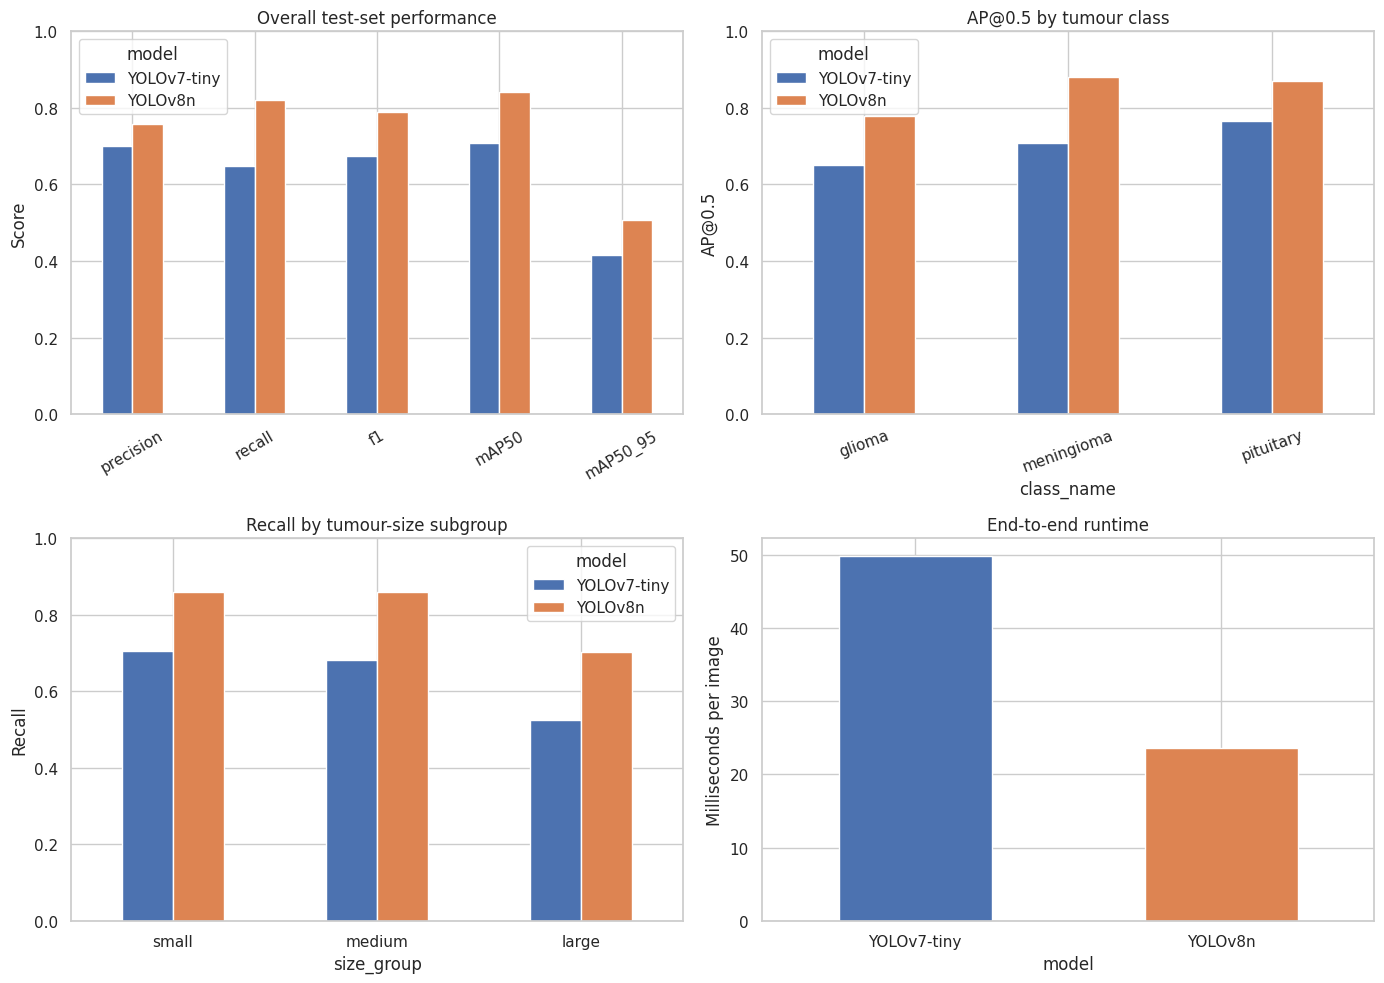

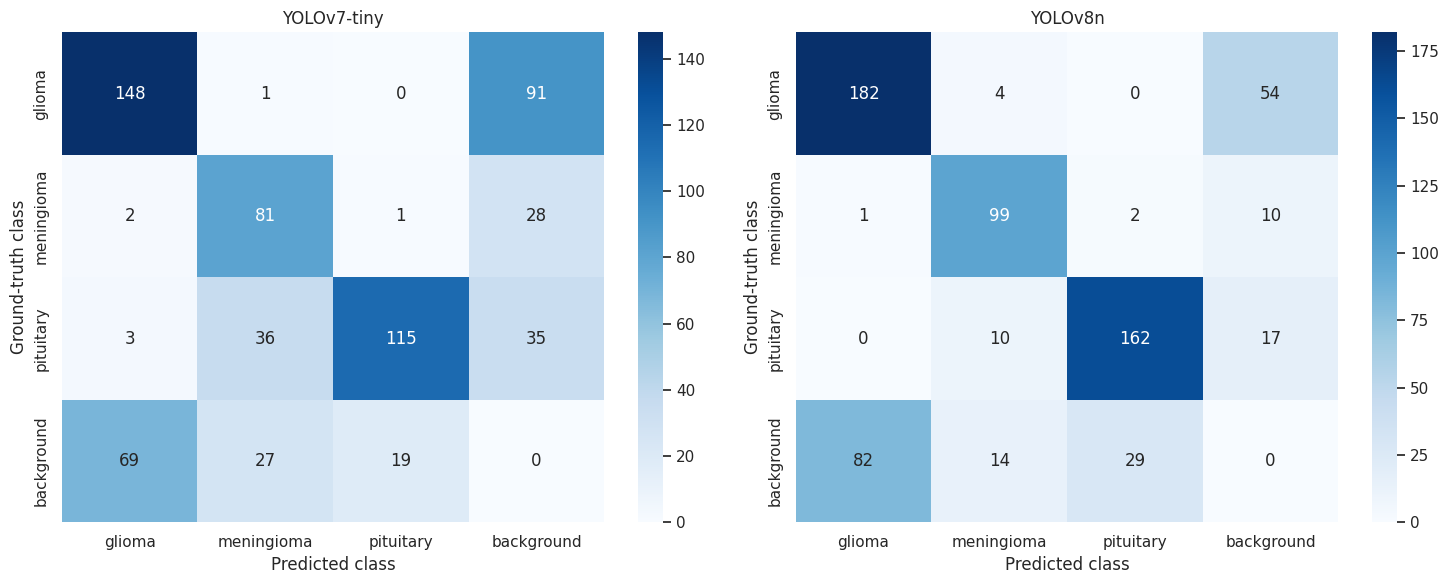

Comparison figure: /content/drive/MyDrive/brain_tumor_yolo_results/phase6_evaluation/run_20260807_181639/model_comparison.png
Confusion matrices: /content/drive/MyDrive/brain_tumor_yolo_results/phase6_evaluation/run_20260807_181639/confusion_matrices.png


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ---------- Summary comparison figure ----------

fig, axes = plt.subplots(
    2,
    2,
    figsize=(14, 10),
)

summary_table.set_index("model")[
    [
        "precision",
        "recall",
        "f1",
        "mAP50",
        "mAP50_95",
    ]
].T.plot.bar(
    ax=axes[0, 0],
)

axes[0, 0].set_title(
    "Overall test-set performance"
)
axes[0, 0].set_ylabel("Score")
axes[0, 0].set_ylim(0, 1)
axes[0, 0].tick_params(
    axis="x",
    rotation=30,
)

per_class_table.pivot(
    index="class_name",
    columns="model",
    values="AP50",
).plot.bar(
    ax=axes[0, 1],
)

axes[0, 1].set_title("AP@0.5 by tumour class")
axes[0, 1].set_ylabel("AP@0.5")
axes[0, 1].set_ylim(0, 1)
axes[0, 1].tick_params(
    axis="x",
    rotation=20,
)

size_table.pivot(
    index="size_group",
    columns="model",
    values="recall",
).reindex([
    "small",
    "medium",
    "large",
]).plot.bar(
    ax=axes[1, 0],
)

axes[1, 0].set_title(
    "Recall by tumour-size subgroup"
)
axes[1, 0].set_ylabel("Recall")
axes[1, 0].set_ylim(0, 1)
axes[1, 0].tick_params(
    axis="x",
    rotation=0,
)

runtime_table.set_index("model")[
    "milliseconds_per_image"
].plot.bar(
    ax=axes[1, 1],
    color=["#4c72b0", "#dd8452"],
)

axes[1, 1].set_title(
    "End-to-end runtime"
)
axes[1, 1].set_ylabel(
    "Milliseconds per image"
)
axes[1, 1].tick_params(
    axis="x",
    rotation=0,
)

plt.tight_layout()

comparison_figure = (
    EVALUATION_ROOT
    / "model_comparison.png"
)

plt.savefig(
    comparison_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()


def detection_confusion_matrix(predictions):
    number_classes = len(CLASS_NAMES)

    matrix = np.zeros(
        (
            number_classes + 1,
            number_classes + 1,
        ),
        dtype=int,
    )

    background_index = number_classes

    for sample_id, labels in (
        ground_truth_by_sample.items()
    ):
        sample_predictions = [
            prediction
            for prediction
            in predictions.get(sample_id, [])
            if prediction["confidence"]
            >= CONFIDENCE_THRESHOLD
        ]

        matched_predictions = set()

        for ground_truth in labels:
            best_iou = 0.0
            best_prediction_index = None

            for index, prediction in enumerate(
                sample_predictions
            ):
                if index in matched_predictions:
                    continue

                current_iou = box_iou(
                    ground_truth["box"],
                    prediction["box"],
                )

                if current_iou > best_iou:
                    best_iou = current_iou
                    best_prediction_index = index

            if (
                best_prediction_index is not None
                and best_iou
                >= MATCH_IOU_THRESHOLD
            ):
                prediction = sample_predictions[
                    best_prediction_index
                ]

                matrix[
                    ground_truth["class_id"],
                    prediction["class_id"],
                ] += 1

                matched_predictions.add(
                    best_prediction_index
                )

            else:
                matrix[
                    ground_truth["class_id"],
                    background_index,
                ] += 1

        for index, prediction in enumerate(
            sample_predictions
        ):
            if index not in matched_predictions:
                matrix[
                    background_index,
                    prediction["class_id"],
                ] += 1

    return matrix


confusion_labels = [
    "glioma",
    "meningioma",
    "pituitary",
    "background",
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 6),
)

for axis, (
    model_name,
    predictions,
) in zip(
    axes,
    predictions_by_model.items(),
):
    matrix = detection_confusion_matrix(
        predictions
    )

    pd.DataFrame(
        matrix,
        index=confusion_labels,
        columns=confusion_labels,
    ).to_csv(
        EVALUATION_ROOT
        / (
            model_name
            .lower()
            .replace("-", "_")
            + "_confusion_matrix.csv"
        )
    )

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=confusion_labels,
        yticklabels=confusion_labels,
        ax=axis,
    )

    axis.set_title(model_name)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Ground-truth class")

plt.tight_layout()

confusion_figure = (
    EVALUATION_ROOT
    / "confusion_matrices.png"
)

plt.savefig(
    confusion_figure,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Comparison figure:", comparison_figure)
print("Confusion matrices:", confusion_figure)

#### Result interpretation

The comparison plots show a consistent aggregate advantage for YOLOv8n. Confusion matrices must still be read with the background row and column: they distinguish class errors, missed ground truths, and unmatched extra predictions.


## Visual error analysis

Representative test images are grouped as correct detections, missed tumours,
class errors, localization errors or detections containing additional false
positives. Green rectangles show ground truth and blue or red rectangles show
model predictions.

### Code — categorize and display representative test errors

Classify each slice as correct, missed, misclassified, poorly localized, or correct with extra detections, then overlay ground truth and predictions for qualitative review.


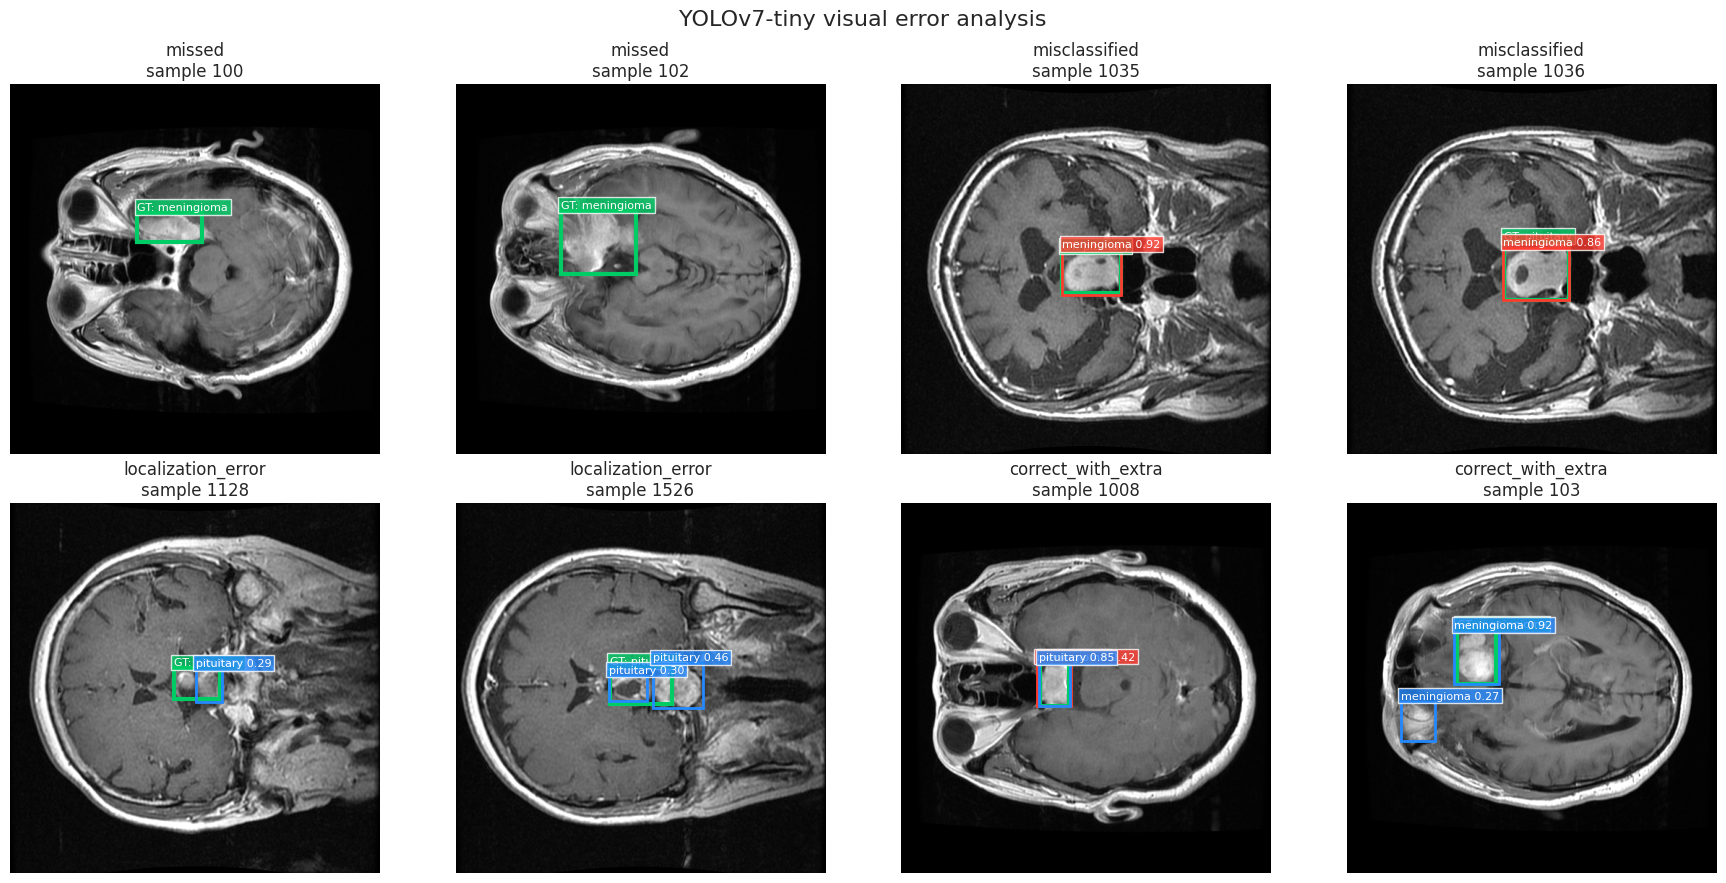

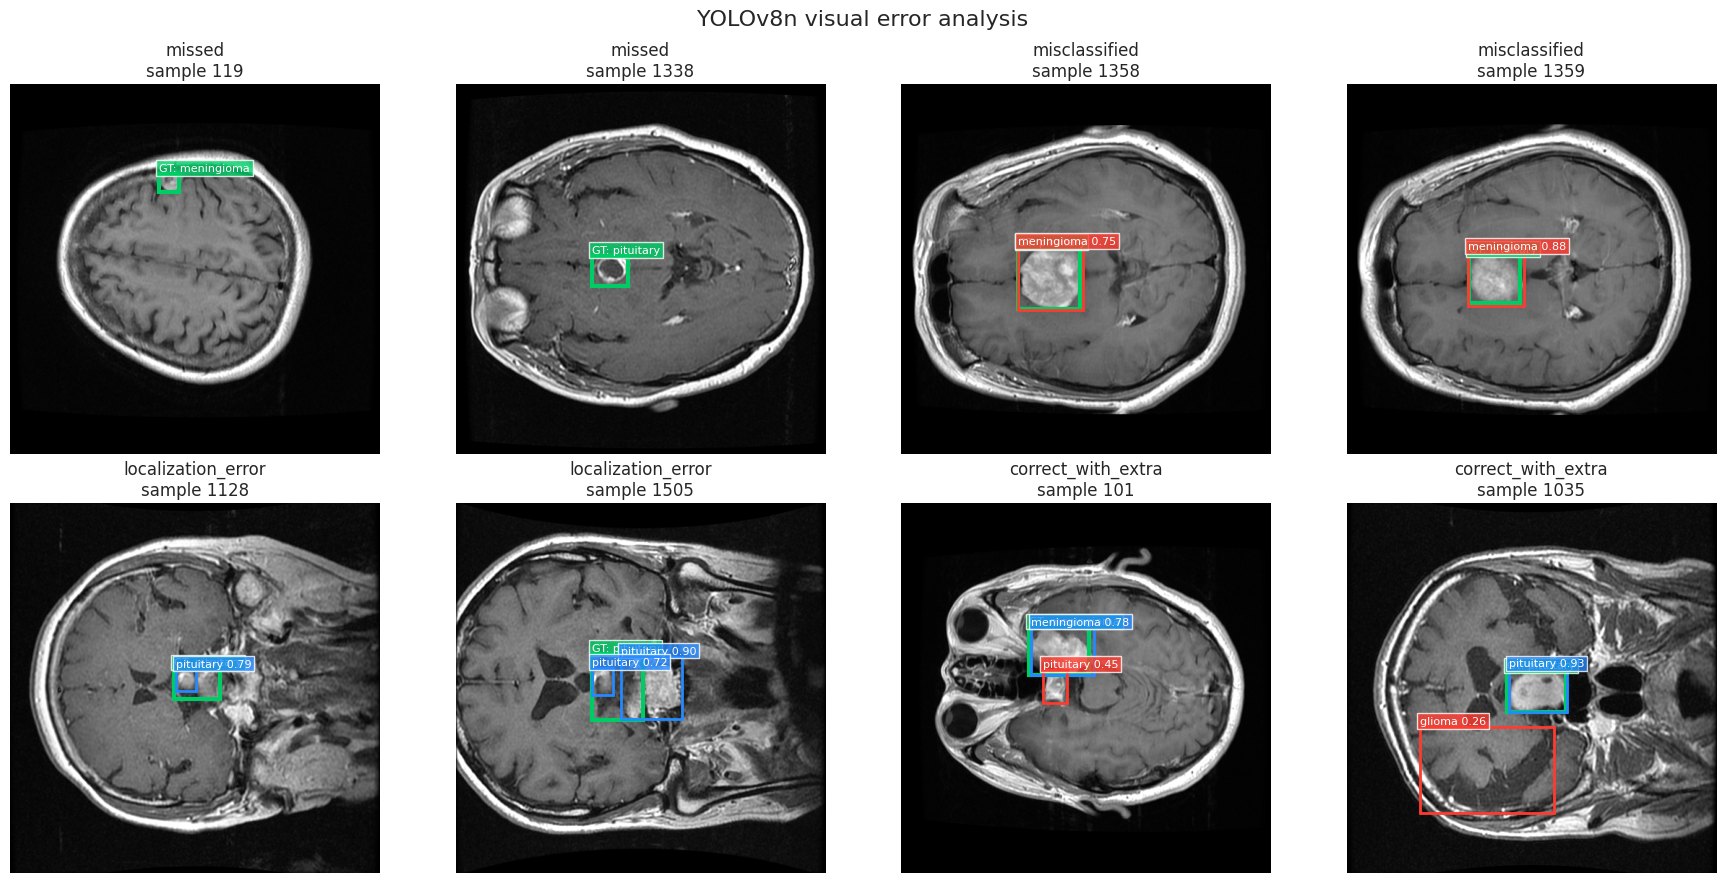

error_type,correct,correct_with_extra,localization_error,misclassified,missed,All
model,,,,,,
YOLOv7-tiny,303,41,47,43,107,541
YOLOv8n,397,46,60,17,21,541
All,700,87,107,60,128,1082


Phase 6 evaluation completed.
All tables and figures are saved under: /content/drive/MyDrive/brain_tumor_yolo_results/phase6_evaluation/run_20260807_181639


In [ ]:
from matplotlib.patches import Rectangle
from PIL import Image

test_row_by_sample = {
    str(row.sample_id): row
    for row in test_df.itertuples(index=False)
}


def classify_detection_error(
    sample_id,
    predictions,
):
    ground_truth = (
        ground_truth_by_sample[sample_id][0]
    )

    valid_predictions = [
        prediction
        for prediction
        in predictions.get(sample_id, [])
        if prediction["confidence"]
        >= CONFIDENCE_THRESHOLD
    ]

    if not valid_predictions:
        return {
            "error_type": "missed",
            "best_iou": 0.0,
            "predicted_class": None,
            "confidence": None,
            "extra_predictions": 0,
        }

    best_prediction = max(
        valid_predictions,
        key=lambda prediction: box_iou(
            ground_truth["box"],
            prediction["box"],
        ),
    )

    best_iou = box_iou(
        ground_truth["box"],
        best_prediction["box"],
    )

    if best_iou < MATCH_IOU_THRESHOLD:
        error_type = "localization_error"

    elif (
        best_prediction["class_id"]
        != ground_truth["class_id"]
    ):
        error_type = "misclassified"

    elif len(valid_predictions) > 1:
        error_type = "correct_with_extra"

    else:
        error_type = "correct"

    return {
        "error_type": error_type,
        "best_iou": best_iou,
        "predicted_class": (
            best_prediction["class_id"]
        ),
        "confidence": (
            best_prediction["confidence"]
        ),
        "extra_predictions": max(
            0,
            len(valid_predictions) - 1,
        ),
    }


error_rows = []

for model_name, predictions in (
    predictions_by_model.items()
):
    for sample_id in test_df["sample_id"]:
        sample_id = str(sample_id)

        status = classify_detection_error(
            sample_id,
            predictions,
        )

        gt_class = (
            ground_truth_by_sample[
                sample_id
            ][0]["class_id"]
        )

        error_rows.append({
            "model": model_name,
            "sample_id": sample_id,
            "patient_id": str(
                test_row_by_sample[
                    sample_id
                ].patient_id
            ),
            "ground_truth_class": (
                CLASS_NAMES[gt_class]
            ),
            "predicted_class": (
                CLASS_NAMES.get(
                    status["predicted_class"],
                    "none",
                )
                if status["predicted_class"]
                is not None
                else "none"
            ),
            **status,
        })

error_table = pd.DataFrame(error_rows)

error_table.to_csv(
    EVALUATION_ROOT
    / "visual_error_audit.csv",
    index=False,
)

priority_order = [
    "missed",
    "misclassified",
    "localization_error",
    "correct_with_extra",
    "correct",
]


def draw_normalized_box(
    axis,
    box,
    image_width,
    image_height,
    color,
    label,
    line_width=2,
):
    xmin = box[0] * image_width
    ymin = box[1] * image_height
    xmax = box[2] * image_width
    ymax = box[3] * image_height

    axis.add_patch(
        Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            fill=False,
            edgecolor=color,
            linewidth=line_width,
        )
    )

    axis.text(
        xmin,
        max(0, ymin - 4),
        label,
        color="white",
        fontsize=8,
        bbox={
            "facecolor": color,
            "alpha": 0.8,
            "pad": 2,
        },
    )


for model_name, predictions in (
    predictions_by_model.items()
):
    model_errors = error_table[
        error_table["model"] == model_name
    ]

    selected_rows = []

    # Select up to two deterministic examples per category.
    for error_type in priority_order:
        category_rows = (
            model_errors[
                model_errors["error_type"]
                == error_type
            ]
            .sort_values("sample_id")
            .head(2)
        )

        selected_rows.extend(
            category_rows.to_dict("records")
        )

        if len(selected_rows) >= 8:
            break

    selected_rows = selected_rows[:8]

    figure, axes = plt.subplots(
        2,
        4,
        figsize=(18, 9),
    )

    for axis, selected in zip(
        axes.flat,
        selected_rows,
    ):
        sample_id = selected["sample_id"]

        manifest_row = (
            test_row_by_sample[sample_id]
        )

        image = Image.open(
            DATASET_ROOT
            / manifest_row.image_path
        ).convert("RGB")

        image_width, image_height = image.size

        axis.imshow(image)

        ground_truth = (
            ground_truth_by_sample[
                sample_id
            ][0]
        )

        draw_normalized_box(
            axis,
            ground_truth["box"],
            image_width,
            image_height,
            "#00cc66",
            (
                "GT: "
                + CLASS_NAMES[
                    ground_truth["class_id"]
                ]
            ),
            line_width=3,
        )

        displayed_predictions = [
            prediction
            for prediction
            in predictions.get(sample_id, [])
            if prediction["confidence"]
            >= CONFIDENCE_THRESHOLD
        ][:5]

        for prediction in displayed_predictions:
            correct_class = (
                prediction["class_id"]
                == ground_truth["class_id"]
            )

            prediction_color = (
                "#2589ff"
                if correct_class
                else "#ff3b30"
            )

            class_name_str = CLASS_NAMES.get(prediction['class_id'], 'unknown')
            prediction_label = f"{class_name_str} {prediction['confidence']:.2f}"

            draw_normalized_box(
                axis,
                prediction["box"],
                image_width,
                image_height,
                prediction_color,
                prediction_label,
            )

        axis.set_title(
            f"{selected['error_type']}\n"
            f"sample {sample_id}"
        )

        axis.axis("off")

    # Hide unused axes.
    for axis in axes.flat[
        len(selected_rows):
    ]:
        axis.axis("off")

    figure.suptitle(
        f"{model_name} visual error analysis",
        fontsize=16,
    )

    plt.tight_layout()

    output_name = (
        model_name
        .lower()
        .replace("-", "_")
        + "_visual_error_analysis.png"
    )

    output_path = (
        EVALUATION_ROOT / output_name
    )

    plt.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

display(
    pd.crosstab(
        error_table["model"],
        error_table["error_type"],
        margins=True,
    )
)

print(
    "Phase 6 evaluation completed."
)

print(
    "All tables and figures are saved under:",
    EVALUATION_ROOT,
)


#### Result interpretation

The recorded audit found that YOLOv8n reduced missed slices from **107 to 21** and class errors from **43 to 17**, but produced more localization errors (60 versus 47) and slightly more cases with extra predictions. Higher recall therefore did not remove every failure mode.


# Phase 7 — Results, conclusions, limitations and future work

## 7.1 Experimental conclusion

This project investigated whether YOLOv8n improves three-class brain-tumour
localization compared with YOLOv7-tiny under a controlled experimental design.
Both detectors used the same contrast-enhanced T1 MRI dataset, patient-level
train/validation/test partition, image size, batch size, epoch budget, optimizer
family, declared augmentation policy, random seed and Tesla T4 GPU. Framework-
specific transformations and internal training implementations remain a limitation.

The independent test set contained 541 MRI slices from 37 patients. It was not
used for model training, hyperparameter selection or checkpoint selection.

### Test-set results

| Metric | YOLOv7-tiny | YOLOv8n | Difference |
|---|---:|---:|---:|
| Precision | 0.699 | **0.759** | +0.060 |
| Recall | 0.649 | **0.821** | +0.172 |
| F1-score | 0.673 | **0.789** | +0.116 |
| mAP@0.5 | 0.708 | **0.842** | +0.135 |
| mAP@0.5:0.95 | 0.416 | **0.507** | +0.090 |
| Small-tumour recall | 0.706 | **0.860** | +0.154 |
| Patient-macro recall | 0.663 | **0.809** | +0.146 |
| Runtime per image | 36.02 ms | **21.79 ms** | −14.23 ms |
| Throughput | 27.76 images/s | **45.89 images/s** | +18.13 images/s |

YOLOv8n reduced end-to-end latency by approximately 39.5% and processed
approximately 65.3% more images per second than YOLOv7-tiny in this experiment.
It therefore provided both better detection performance and greater
computational efficiency.

## 7.2 Tumour-class performance

| Tumour class | Test instances | YOLOv7 AP@0.5 | YOLOv8 AP@0.5 |
|---|---:|---:|---:|
| Glioma | 240 | 0.651 | **0.778** |
| Meningioma | 112 | 0.707 | **0.880** |
| Pituitary | 189 | 0.765 | **0.870** |

YOLOv8n produced higher AP@0.5 for every tumour class. Its strongest class-level
result was obtained for meningioma, with AP@0.5 of 0.880 and recall of 0.893.
Glioma remained the most difficult class for both models, although YOLOv8n
improved glioma recall from 0.621 to 0.758.

The results indicate that the overall improvement was not caused by only one
tumour category. YOLOv8n improved localization and classification across
glioma, meningioma and pituitary cases.

## 7.3 Tumour-size analysis

Small tumours were defined as bounding boxes in the lowest quartile of
normalized test-set tumour area. The normalized area threshold was approximately
0.0103.

| Size group | YOLOv7 recall | YOLOv8 recall |
|---|---:|---:|
| Small | 0.706 | **0.860** |
| Medium | 0.682 | **0.859** |
| Large | 0.526 | **0.704** |

YOLOv8n improved recall in all three size groups. In particular, small-tumour
recall increased by 15.4 percentage points. This supports the hypothesis that
YOLOv8n can provide more reliable localization of relatively small tumour
regions within this dataset.

The lower recall observed for the large-box subgroup should not be interpreted
as evidence that larger tumours are inherently more difficult to identify.
Large masks may be more heterogeneous, irregular or difficult to match at the
selected IoU threshold. This pattern requires additional investigation.

## 7.4 Visual error analysis

At a confidence threshold of 0.25 and matching IoU threshold of 0.50, the visual
audit produced the following categories:

| Error category | YOLOv7-tiny | YOLOv8n |
|---|---:|---:|
| Correct | 303 | **397** |
| Correct with additional prediction | 41 | 46 |
| Localization error | **47** | 60 |
| Misclassified | 43 | **17** |
| Missed | 107 | **21** |

YOLOv8n reduced missed cases from 107 to 21, a reduction of approximately
80.4%. It also reduced class errors from 43 to 17. However, YOLOv8n produced
slightly more localization errors and additional predictions. This shows that
its higher recall did not eliminate every failure mode.

The visual results suggest that future optimization should focus on bounding-box
localization quality, confidence calibration and suppression of duplicate or
additional detections.

## 7.5 Model selected for demonstration

YOLOv8n is selected as the default model for the demonstration because it
achieved:

- Higher precision, recall and F1-score
- Higher mAP at both reported IoU criteria
- Higher recall for every tumour-size subgroup
- Higher AP@0.5 for every tumour class
- Higher patient-level recall
- Lower inference time and greater throughput
- Substantially fewer missed and misclassified tumours

YOLOv7-tiny remains available in the interface for educational comparison.


## 7.6 Limitations

This study has several important limitations:

1. **No healthy controls:** Every image contains a tumour. Consequently,
   specificity, true-negative rate and performance on normal MRI images cannot
   be estimated.

2. **Single imaging modality:** The dataset contains contrast-enhanced T1 MRI
   slices only. T2, FLAIR and other complementary sequences were unavailable.

3. **Two-dimensional analysis:** Each slice was processed independently. The
   models did not use neighbouring slices or complete three-dimensional tumour
   context.

4. **Single source dataset:** Performance may depend on the acquisition
   protocols, scanners, institutions and patient population represented in the
   original dataset.

5. **Limited demographic metadata:** Age, sex, ethnicity and other clinical
   variables were unavailable or incomplete, preventing demographic fairness
   analysis.

6. **Bounding boxes derived from masks:** Tight rectangular boxes simplify
   irregular tumour boundaries and do not provide the detailed information
   available from segmentation masks.

7. **Class imbalance:** The test set contained 240 glioma, 112 meningioma and
   189 pituitary slices. The smaller meningioma sample introduces greater
   uncertainty into its class-specific estimates.

8. **Single random seed:** Both models were trained with seed 41. Multiple
   independent training runs are required to estimate variability caused by
   initialization and stochastic optimization.

9. **Framework differences:** Although the controllable training settings were
   aligned, YOLOv7 and YOLOv8 use different architectures, loss functions,
   label-assignment methods and internal training implementations.

10. **No external validation:** The models were not evaluated on data from an
    independent hospital or imaging centre.

11. **Descriptive size threshold:** The small-tumour category was defined using
    the lowest quartile of test-set box area rather than a clinically validated
    size threshold.

12. **Runtime measurement:** Runtime included model loading, preprocessing,
    inference, postprocessing and prediction export. It should not be interpreted
    as isolated neural-network latency.

13. **Not clinically validated:** The project is an educational research
    prototype and is not suitable for diagnosis, screening, triage or treatment
    decisions.

## 7.7 Ethical considerations

MRI data are sensitive medical information. Any future dataset must be properly
de-identified, stored securely and used according to its licence and data-use
agreement.

A model trained on a limited population may perform differently across
institutions, scanner manufacturers and demographic groups. Incorrect
predictions could create false reassurance or unnecessary concern. Therefore,
predictions must remain subject to qualified clinical interpretation.

The demonstration must not request identifying patient information, permanently
store uploaded images or describe its output as a medical diagnosis.

## 7.8 Future work

Future development should:

- Add properly sourced healthy and no-tumour MRI controls
- Perform external validation on an independent multi-centre dataset
- Repeat training with multiple random seeds and report confidence intervals
- Evaluate performance across scanner, institution and demographic subgroups
- Add T2 and FLAIR sequences for a genuine multimodal experiment
- Investigate three-dimensional detection and volumetric segmentation
- Compare object detection with tumour-segmentation architectures
- Evaluate confidence calibration and uncertainty estimation
- Investigate localization errors for large and irregular tumours
- Optimize confidence and non-maximum-suppression thresholds using validation
  data only
- Conduct blinded review with qualified radiologists
- Assess robustness to image artefacts and acquisition differences
- Develop privacy-preserving and auditable deployment procedures


## Final conclusion

Within the limits of this dataset and experimental design, YOLOv8n was the
stronger detector. It achieved better aggregate accuracy, better class-level
performance, higher small-tumour and patient-level recall, fewer missed cases
and faster inference than YOLOv7-tiny.

The results support selecting YOLOv8n for the project demonstration. They do not
establish clinical effectiveness or generalization beyond the evaluated public
dataset. External validation, healthy controls, repeated training and clinical
review are required before considering any real healthcare application.